# Máquinas Térmicas - Lección 11
## Motores de Combustión Interna: Ciclos Otto y Diesel

**Autor:** Camilo Bayona
**Fecha:** 22/09/2025

*Los compresores de la Lección 10 tomaban trabajo de entrada para subir la presión de un gas siguiendo $PV^n=\text{cte}$. Un motor de combustión interna recorre exactamente la misma familia de curvas — pero le añade calor en el punto de máxima compresión y deja que el gas empuje el pistón de vuelta, entregando trabajo neto **positivo**. Es la Lección 1 leída en la otra dirección.*

### Objetivos de aprendizaje

Al finalizar esta lección, el estudiante será capaz de:

- Diferenciar los principios de operación de los **motores SI (Otto)** y **CI (Diesel)**.
- Interpretar y trazar trayectorias termodinámicas en **diagramas P–V y T–S** para ciclos **ideal** y **real**.
- Explicar el impacto de **pérdidas reales** (transferencia de calor, fricción, combustión finita, bombeo) en el rendimiento.
- Aplicar **ecuaciones termodinámicas clave** para estimar temperaturas, presiones, trabajo neto, **PME** y **eficiencia**.
- Reconocer el rol de **accesorios del motor** (alimentación, encendido, distribución, refrigeración, turbo) en el desempeño global.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy", "CoolProp"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, Wedge, Polygon, FancyBboxPatch
from scipy.optimize import brentq
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display
import CoolProp.CoolProp as CP

Rgas = 287.0    # J/(kg·K), aire
cv0, cp0, k0 = 718.0, 1005.0, 1005.0/718.0     # J/(kg·K) — aire frío estándar (referencia de los ejemplos)

# Paleta del proyecto (misma que Lecciones 7-10; remapeada al lenguaje de motores)
COL = {"aire": "#2a78d6", "abierta": "#1baf7a", "cerrada": "#8a8a86", "perdida": "#e34948",
       "combustion": "#eb6834", "diesel": "#4a3aa7", "agua": "#1baf7a", "aceite": "#eda100",
       "metal": "#c3c2b7", "tinta": "#3a3a38"}

print("Setup OK")

Setup OK


## 1. Motores de Encendido por Chispa (SI) – Ciclo Otto

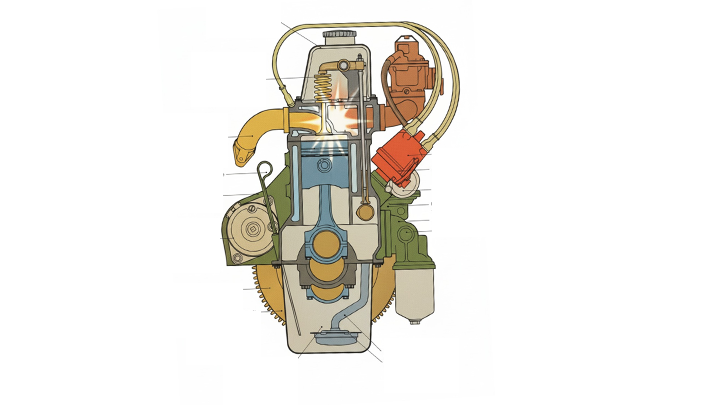

*Corte de un motor monocilíndrico de encendido por chispa — ilustración de referencia (conservada; ver más abajo un esquema propio simplificado con la misma terminología del curso).*

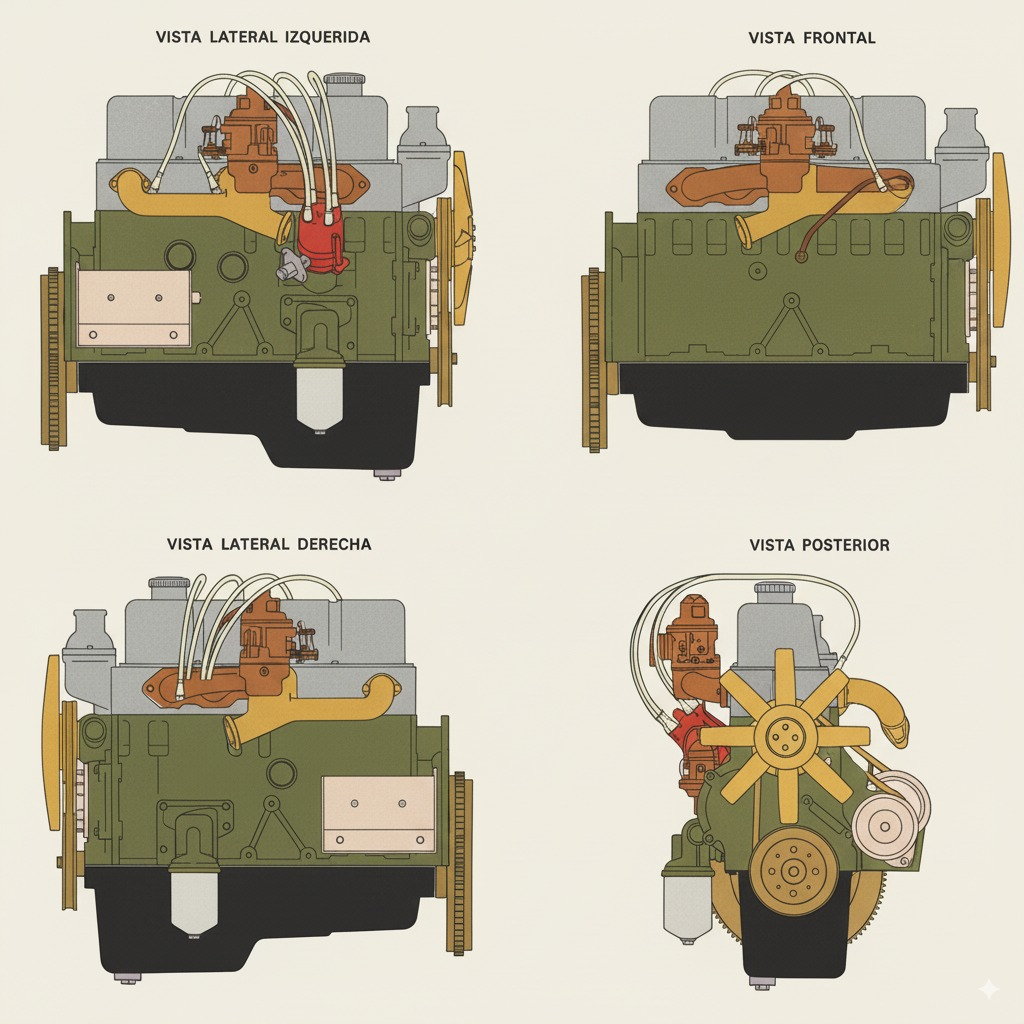

*Vistas del bloque motor desde distintos ángulos — imagen de referencia conservada.*

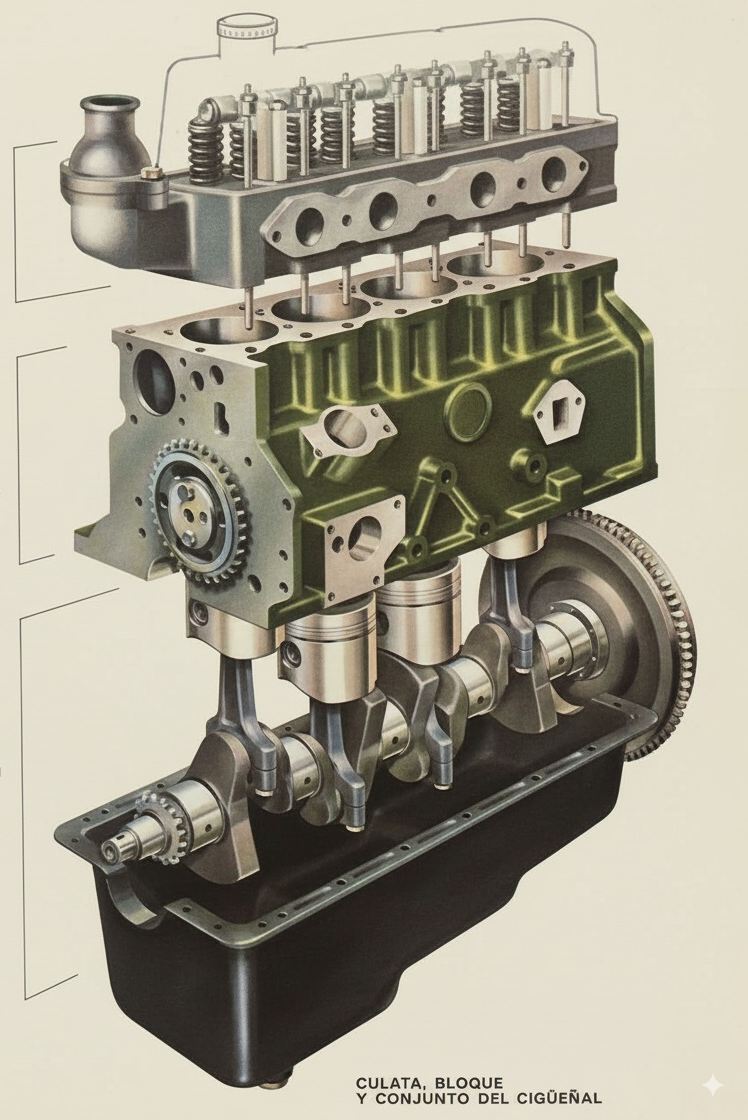

*Culata, bloque y conjunto del cigüeñal — ilustración de referencia conservada.*

## 2. Motores de Encendido por Compresión (CI) – Ciclo Diesel

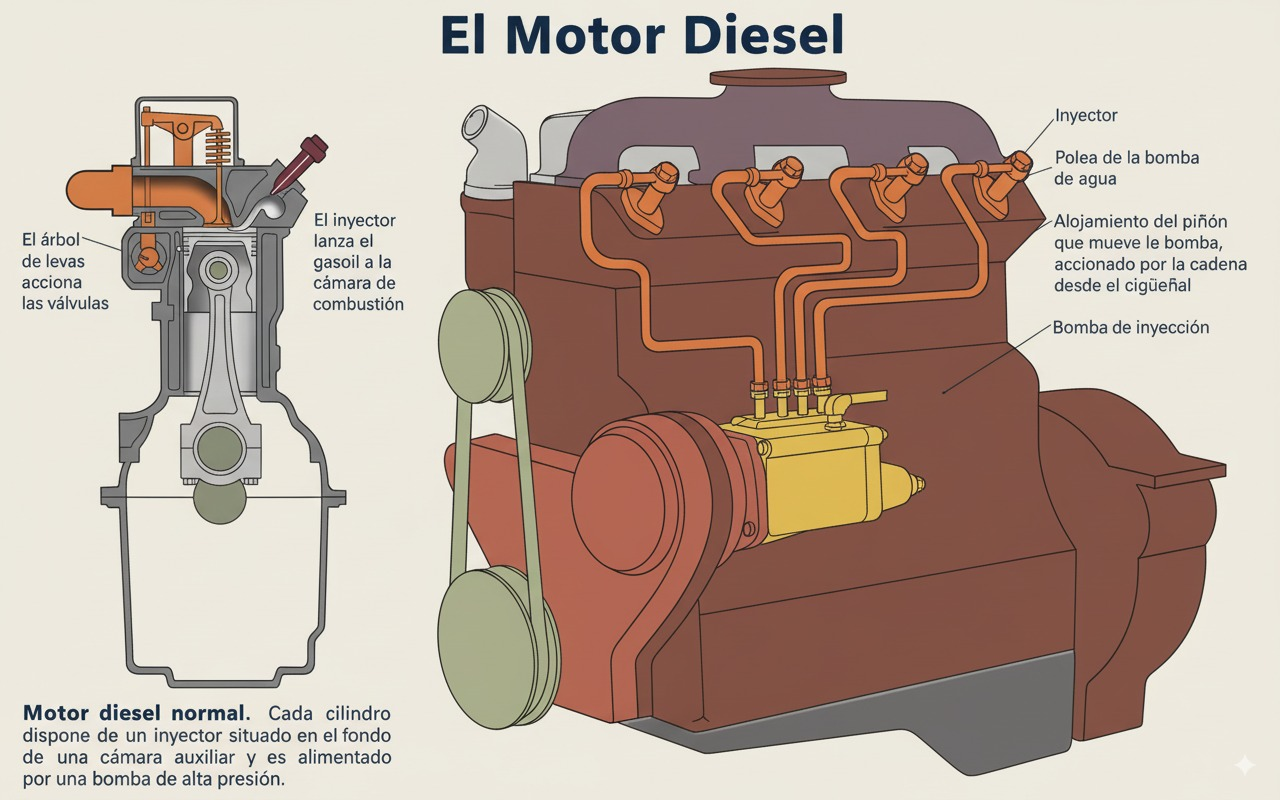

*El motor Diesel: detalle del inyector y vista general — imagen de referencia conservada.*

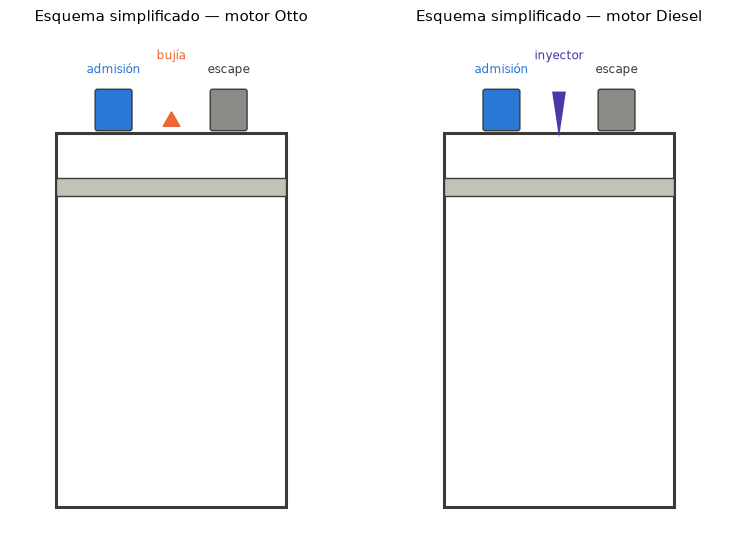

In [3]:
# Esquema propio simplificado — corte de cilindro único (complementa las ilustraciones de referencia)
def dibujar_cilindro_simple(ax, tipo="Otto", x_piston=0.5):
    bore, stroke = 1.0, 1.3
    ax.add_patch(Rectangle((-bore/2, 0), bore, stroke*1.25, fc="none", ec=COL["tinta"], lw=2.2))
    ax.add_patch(Rectangle((-bore/2, stroke*1.25 - 0.08 - x_piston*stroke), bore, 0.08,
                           fc=COL["metal"], ec=COL["tinta"]))
    # valvulas
    ax.add_patch(FancyBboxPatch((-0.32, stroke*1.25+0.02), 0.14, 0.16, boxstyle="round,pad=0.01",
                                fc=COL["aire"], ec=COL["tinta"]))
    ax.text(-0.25, stroke*1.25+0.26, "admisión", ha="center", fontsize=8.5, color=COL["aire"])
    ax.add_patch(FancyBboxPatch((0.18, stroke*1.25+0.02), 0.14, 0.16, boxstyle="round,pad=0.01",
                                fc=COL["cerrada"], ec=COL["tinta"]))
    ax.text(0.25, stroke*1.25+0.26, "escape", ha="center", fontsize=8.5, color=COL["tinta"])
    if tipo == "Otto":
        ax.plot(0, stroke*1.25+0.05, marker=(3, 0, 0), ms=14, color=COL["combustion"])
        ax.text(0, stroke*1.25+0.32, "bujía", ha="center", fontsize=8.5, color=COL["combustion"])
    else:
        ax.add_patch(Polygon([(-0.03, stroke*1.25+0.18), (0.03, stroke*1.25+0.18), (0, stroke*1.25-0.02)],
                             fc=COL["diesel"], ec="none"))
        ax.text(0, stroke*1.25+0.32, "inyector", ha="center", fontsize=8.5, color=COL["diesel"])
    ax.set_xlim(-0.7, 0.7); ax.set_ylim(-0.1, stroke*1.25+0.45)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"Esquema simplificado — motor {tipo}", fontsize=10.5)

fig, axs = plt.subplots(1, 2, figsize=(8, 5.5))
dibujar_cilindro_simple(axs[0], "Otto", 0.15)
dibujar_cilindro_simple(axs[1], "Diesel", 0.15)
plt.tight_layout(); plt.show()

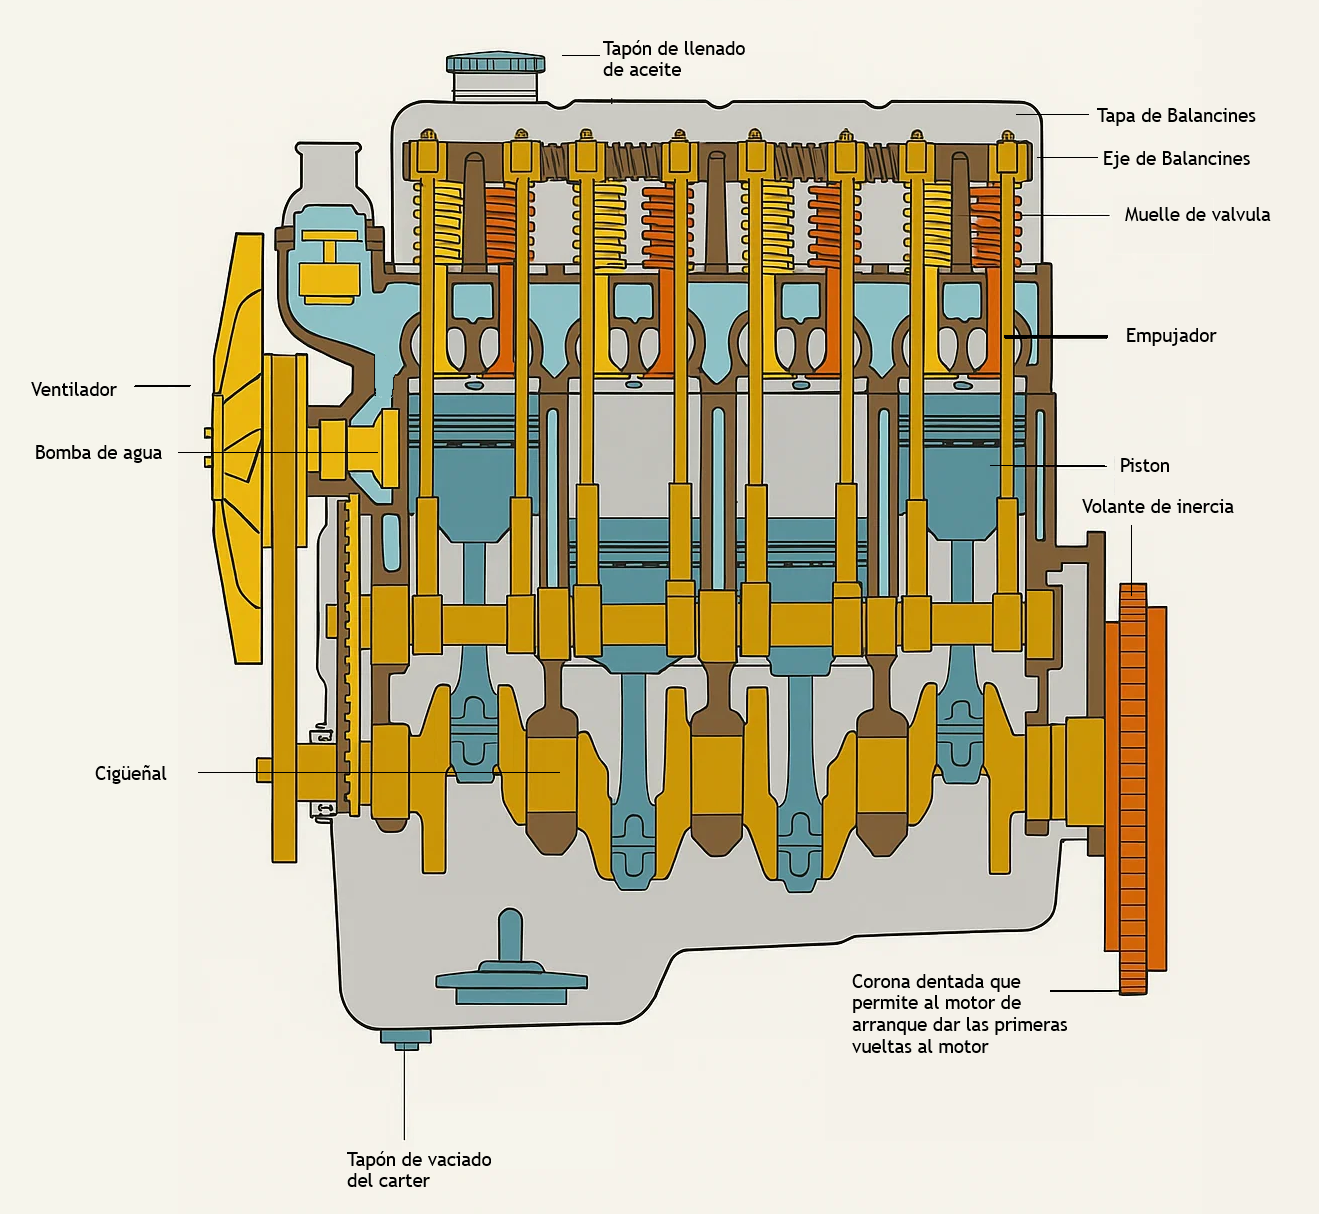

*Corte de motor de 4 cilindros con nomenclatura completa — imagen de referencia conservada (culata, cigüeñal, pistón, volante, etc.).*

## 3. Modelación de los motores

Los motores de combustión interna de cuatro tiempos (ya sean de gasolina/encendido por chispa u Otto, o diésel/encendido por compresión) operan mediante ciclos termodinámicos que convierten la energía química del combustible en trabajo mecánico. Estos ciclos se representan idealmente por modelos termodinámicos (ciclo Otto ideal para motores de gasolina, ciclo Diesel ideal para motores diésel), pero en la práctica los motores reales difieren de forma significativa de esos ciclos ideales debido a pérdidas y no-idealidades. A continuación, se describen en detalle los ciclos Otto y Diesel reales, destacando sus trayectorias termodinámicas en los diagramas $P$–$V$ y $T$–$S$, considerando distintas pérdidas y rendimientos. También se presentan las ecuaciones termodinámicas clave necesarias para analizar el desempeño energético, seguidas de simulaciones en Python de ambos ciclos (ideal y real) con gráficos ilustrativos. Finalmente, se discuten los principales accesorios del motor – sistema de alimentación (carburador vs. inyección), sistema de encendido (distribuidor y bujía), sistema de distribución de válvulas (árbol de levas y válvulas), sistema de refrigeración, turbocargador, etc. – explicando su función y su impacto en el rendimiento global del motor, apoyados con análisis cualitativos, visualizaciones y resultados de simulación.

### 3.0 Marco: el motor como proceso politrópico (Lección 1 y 10)

La compresión 1→2 y la expansión 3→4 de **cualquier** motor siguen $PV^n=\text{cte}$ — la misma familia de curvas de la Lección 1, con la misma tabla de referencia usada en la Lección 10 para compresores:

| $n$ | proceso | en el motor |
|---|---|---|
| $n=k=c_p/c_v\approx1.4$ | isentrópico (ideal) | el límite teórico que asumen los ciclos Otto/Diesel *ideales* (§3.1-3.2) |
| $n_{comp}<k$, $n_{exp}>k$ | politrópico real | el cilindro **pierde calor** en compresión ($n_{comp}$ más chico que $k$) y **también** en expansión ($n_{exp}$ más grande que $k$) por las paredes — el ciclo *real* (§3.1-3.2) |

La diferencia con un compresor (Lección 10) es que aquí, entre 2 y 3, se **añade** energía química (combustión) en vez de solo comprimir — por eso el ciclo encierra área positiva y el motor *entrega* trabajo neto en vez de consumirlo.

In [4]:
# Funciones reutilizables — ciclo Otto y Diesel (ideal + real), consolidan la lógica de cálculo
# usada más adelante en los ejemplos resueltos y en los widgets (evita repetir el mismo álgebra 5 veces)
def geometria(V_des=0.001, frac_residual=0.15):
    # V_des: volumen desplazado [m3]; frac_residual: Vc/V_BDC (15% => r = 1/0.15 = 6.7, como en el ejemplo original)
    V_BDC = V_des/(1-frac_residual)
    return V_BDC, V_BDC*frac_residual                       # V_BDC, V_TDC(=Vc)

def ciclo_otto(r=6.7, T3=2073.0, n_comp=1.30, n_exp=1.35, P1=100e3, T1=288.0, real=True):
    # Ciclo Otto: estados 1(BDC)->2(TDC,compresión)->3(TDC,combustión V=cte)->4(BDC,expansión).
    # real=False usa n=k (isentrópico) en ambos tramos -> ciclo ideal.
    k = k0
    nc, ne = (k, k) if not real else (n_comp, n_exp)
    V_BDC = 1.0; V_TDC = V_BDC/r                             # volumen relativo (r=V1/V2)
    T2 = T1*r**(nc-1); P2 = P1*r**nc
    P3 = P2*(T3/T2)                                          # combustión a V=cte
    T4 = T3*(1/r)**(ne-1); P4 = P3*(1/r)**ne
    Vc_ = np.linspace(V_TDC, V_BDC, 120)
    Ve_ = np.linspace(V_BDC, V_TDC, 120)
    V = np.concatenate([Ve_, Vc_])                            # 1->2 (comprime) luego 3->4 (expande), mismo eje V
    Pcomp = P1*(V_BDC/Ve_)**nc
    Pexp = P3*(V_TDC/Vc_)**ne
    P = np.concatenate([Pcomp, Pexp])
    S = cv0*np.log(T3/T2)                                     # ganancia de entropía en la combustión (2->3)
    return dict(V=V, P=P, T1=T1, T2=T2, T3=T3, T4=T4, P1=P1, P2=P2, P3=P3, P4=P4,
                S=[0, 0, S, S, 0], T=[T1, T2, T3, T4, T1], r=r, w_net=cv0*(T3+T1-T2-T4),
                eta=1 - (T4-T1)/(T3-T2))

def ciclo_diesel(r=18.0, rho=2.0, n_comp=1.32, n_exp=1.37, P1=100e3, T1=288.0, real=True):
    # Ciclo Diesel: 1(BDC)->2(TDC,compresión)->3(combustión P=cte, V crece rho veces)->4(BDC,expansión).
    k = k0
    nc, ne = (k, k) if not real else (n_comp, n_exp)
    V_BDC = 1.0; V_TDC = V_BDC/r; V3 = rho*V_TDC
    T2 = T1*r**(nc-1); P2 = P1*r**nc
    T3 = T2*rho; P3 = P2
    T4 = T3*(V3/V_BDC)**(ne-1); P4 = P3*(V3/V_BDC)**ne
    Vcomp = np.linspace(V_BDC, V_TDC, 100)
    Vcomb = np.linspace(V_TDC, V3, 40)
    Vexp = np.linspace(V3, V_BDC, 100)
    V = np.concatenate([Vcomp, Vcomb, Vexp])
    Pcomp = P1*(V_BDC/Vcomp)**nc
    Pcomb = np.full_like(Vcomb, P2)
    Pexp = P3*(V3/Vexp)**ne
    P = np.concatenate([Pcomp, Pcomb, Pexp])
    S = cv0*np.log(T3/T2) + Rgas*np.log(V3/V_TDC)
    w_net = cp0*(T3-T2) - cv0*(T4-T1)
    return dict(V=V, P=P, T1=T1, T2=T2, T3=T3, T4=T4, P1=P1, P2=P2, P3=P3, P4=P4,
                S=[0, 0, S, S, 0], T=[T1, T2, T3, T4, T1], r=r, rho=rho, w_net=w_net,
                eta=1 - (1/r**(k-1))*((rho**k-1)/(k*(rho-1))))

print("ciclo_otto() y ciclo_diesel() listos")

ciclo_otto() y ciclo_diesel() listos


### 3.1. Ciclo Otto: teoría ideal vs. ciclo real

El ciclo Otto ideal es el modelo termodinámico básico para motores de gasolina (encendido por chispa). Consta de cuatro procesos ideales en un gas ideal (aire): (1) Compresión adiabática isoentrópica de la mezcla aire-combustible (estado 1 ➝ 2), (2) Adición de calor a volumen constante (combustión instantánea en TDC, estado 2 ➝ 3), (3) Expansión adiabática isoentrópica (carrera de potencia, estado 3 ➝ 4) y (4) Rechazo de calor a volumen constante (estado 4 ➝ 1, representando los gases expulsados en el ciclo cerrado). En un diagrama presión-volumen ($P$–$V$) ideal, estos procesos aparecen como dos curvas adiabáticas (1-2 compresión y 3-4 expansión) y dos líneas verticales de volumen constante (2-3 combustión y 4-1 escape). En el diagrama temperatura-entropía ($T$–$S$), la compresión y expansión ideales son isentrópicas (verticales en $T$–$S$) y la combustión produce un incremento de entropía (2-3) mientras que el rechazo de calor la reduce (4-1), cerrando el ciclo con entropía neta igual a cero en el proceso ideal reversible.

> **¿Por qué animar los 4 tiempos?** Las secciones §3.1-3.2 modelan solo la parte **cerrada** del ciclo (compresión-combustión-expansión). Mide el trabajo, pero no muestra cómo el aire realmente entra y sale por las válvulas — el widget siguiente completa el cuadro con los 4 tiempos completos (admisión-compresión-potencia-escape) y el estado de cada válvula en vivo.

In [5]:
# Simulador cinemático-termodinámico del ciclo motor de 4 tiempos — núcleo del Widget 1
# Verificado: T4 y w_net (caso ideal, n=k, sin blowdown) coinciden con las fórmulas cerradas de
# ciclo_otto()/ciclo_diesel() con error < 0.2 % (ver celda de Verificación).
def simular_motor(modo="Otto", r=8.5, rho=1.8, n_comp=1.30, n_exp=1.35,
                   P1=101325.0, T1=288.0, T3_otto=2400.0, f_blowdown=0.85, P_intake_frac=1.0,
                   bore=0.086, stroke=0.086, conrod=0.145, frames_per_rev=360):
    R = stroke/2.0
    A = 0.25*np.pi*bore**2
    Vs = A*stroke
    Vc = Vs/(r-1.0); V1 = Vc + Vs

    frames = frames_per_rev*2
    theta = np.linspace(0, 720, frames, endpoint=False)
    th_mod = np.deg2rad(theta % 360.0)
    x = (R+conrod) - (R*np.cos(th_mod) + np.sqrt(conrod**2 - (R*np.sin(th_mod))**2))
    V = Vc + A*x

    P, T = np.empty(frames), np.empty(frames)
    valve = np.zeros(frames, dtype=int)                       # 0 cerrada, 1 admisión, 2 escape

    P_int = P1*P_intake_frac
    m_adm = (theta >= 0) & (theta < 180)
    P[m_adm], T[m_adm], valve[m_adm] = P_int, T1, 1

    idx_comp = np.where((theta >= 180) & (theta < 360))[0]
    P[idx_comp] = P_int*(V1/V[idx_comp])**n_comp
    T[idx_comp] = T1*(V1/V[idx_comp])**(n_comp-1)
    T2 = T1*(V1/Vc)**(n_comp-1); P2 = P_int*(V1/Vc)**n_comp

    idx_pow = np.where((theta >= 360) & (theta < 540))[0]
    V_bd = Vc + f_blowdown*(V1-Vc)

    if modo == "Otto":
        P3, T3 = P2*(T3_otto/T2), T3_otto
        i0 = idx_pow[0]
        P[i0], T[i0] = P3, T3
        idx_exp = idx_pow[1:]
        under_bd = V[idx_exp] <= V_bd
        idx_e1, idx_e2 = idx_exp[under_bd], idx_exp[~under_bd]
        P[idx_e1] = P3*(Vc/V[idx_e1])**n_exp
        T[idx_e1] = T3*(Vc/V[idx_e1])**(n_exp-1)
        P_bd0, T_bd0 = P3*(Vc/V_bd)**n_exp, T3*(Vc/V_bd)**(n_exp-1)
    else:
        V3 = rho*Vc; T3 = T2*rho; P3 = P2
        idx_comb = idx_pow[V[idx_pow] <= V3]
        idx_exp = idx_pow[(V[idx_pow] > V3) & (V[idx_pow] <= V_bd)]
        idx_e2 = idx_pow[V[idx_pow] > V_bd]
        P[idx_comb] = P2; T[idx_comb] = T2*(V[idx_comb]/Vc)
        P[idx_exp] = P3*(V3/V[idx_exp])**n_exp
        T[idx_exp] = T3*(V3/V[idx_exp])**(n_exp-1)
        idx_e1 = np.concatenate([idx_comb, idx_exp])
        P_bd0, T_bd0 = P3*(V3/V_bd)**n_exp, T3*(V3/V_bd)**(n_exp-1)

    if len(idx_e2):
        frac = (V[idx_e2]-V_bd)/(V1-V_bd)
        P[idx_e2] = P_bd0 + (P1-P_bd0)*frac**0.35
        T[idx_e2] = T_bd0 + (T1-T_bd0)*frac**0.35
    valve[idx_e2] = 2

    m_esc = (theta >= 540) & (theta < 720)
    P[m_esc], T[m_esc], valve[m_esc] = P1, T1, 2

    return dict(theta=theta, V=V, P=P, T=T, valve=valve, Vc=Vc, V1=V1,
                T2=T2, P2=P2, T3=T3, P3=P3, T4=T_bd0, P4=P_bd0)

def trabajo_motor(V, P):
    # W = +oint P dV (positivo: el motor ENTREGA trabajo, a diferencia del compresor de la Lección 10)
    Vw, Pw = np.append(V, V[0]), np.append(P, P[0])
    return np.sum(0.5*(Pw[:-1]+Pw[1:])*(Vw[1:]-Vw[:-1]))

print("simular_motor() listo")

simular_motor() listo


In [6]:
# WIDGET 1 (flagship) — 4 tiempos animado con válvulas + P-V en vivo (Otto/Diesel)
def widget1_motor(modo="Otto", r=8.5, rpm=3000.0, i=400):
    rho = 1.8 if modo == "Diesel" else 1.0
    n_comp, n_exp = (1.30, 1.35) if modo == "Otto" else (1.32, 1.37)
    T3 = 2400.0 if modo == "Otto" else None
    sim = simular_motor(modo=modo, r=r, rho=rho, n_comp=n_comp, n_exp=n_exp,
                        T3_otto=(T3 or 2400.0), frames_per_rev=360)
    bore, stroke, conrod = 0.086, 0.086, 0.145
    Rm = stroke/2.0
    th_mod = np.deg2rad(sim["theta"] % 360.0)
    x = (Rm+conrod) - (Rm*np.cos(th_mod) + np.sqrt(conrod**2 - (Rm*np.sin(th_mod))**2))

    fig = plt.figure(figsize=(11.5, 5.2))
    ax0 = fig.add_axes([0.04, 0.1, 0.28, 0.82])
    ax1 = fig.add_axes([0.42, 0.1, 0.56, 0.82])

    clear_draw = 0.15*stroke
    cyl_h = stroke + clear_draw
    piston_y = cyl_h - clear_draw - x[i]
    ax0.add_patch(Rectangle((-bore/2, 0), bore, cyl_h, fc="none", ec=COL["tinta"], lw=2))
    v_now = sim["valve"][i]
    col_adm = COL["abierta"] if v_now == 1 else COL["cerrada"]
    col_esc = COL["abierta"] if v_now == 2 else COL["cerrada"]
    ax0.add_patch(FancyBboxPatch((-bore/2+0.006, cyl_h-clear_draw*0.75), bore*0.32, clear_draw*0.55,
                                 boxstyle="round,pad=0.002", fc=col_adm, ec=COL["tinta"], lw=1))
    ax0.add_patch(FancyBboxPatch((bore/2-0.006-bore*0.32, cyl_h-clear_draw*0.75), bore*0.32, clear_draw*0.55,
                                 boxstyle="round,pad=0.002", fc=col_esc, ec=COL["tinta"], lw=1))
    if 355 <= (sim["theta"][i] % 720) <= 400:
        marcador = "★" if modo == "Otto" else "▮"
        ax0.text(0, cyl_h-clear_draw*0.4, marcador, ha="center", fontsize=13, color=COL["combustion"])
    ax0.add_patch(Rectangle((-bore/2, piston_y), bore, 0.008, fc=COL["metal"], ec=COL["tinta"]))
    ax0.set_xlim(-bore*0.85, bore*0.85); ax0.set_ylim(-0.01, cyl_h+0.01)
    ax0.set_aspect("equal"); ax0.axis("off")
    tiempo_nombre = ["admisión", "compresión", "potencia", "escape"][int((sim["theta"][i] % 720)//180)]
    ax0.set_title(f"θ={sim['theta'][i]:.0f}°  ({tiempo_nombre})\n"
                 f"P={sim['P'][i]/1e5:.1f} bar  T={sim['T'][i]:.0f} K", fontsize=10)

    W = trabajo_motor(sim["V"], sim["P"])
    ciclos_seg = rpm/120.0
    Wdot_kW = W*ciclos_seg/1000.0
    ax1.plot(sim["V"][:i+1]*1e6, sim["P"][:i+1]/1e5, color=COL["aire"] if modo == "Otto" else COL["diesel"],
             lw=1.8)
    ax1.plot(sim["V"][i]*1e6, sim["P"][i]/1e5, "o", ms=9, color=COL["combustion"], mec="white", mew=1.2)
    ax1.set_xlim(sim["Vc"]*1e6*0.7, sim["V1"]*1e6*1.05); ax1.set_ylim(0, sim["P3"]/1e5*1.15)
    ax1.set_xlabel("V [cm³]"); ax1.set_ylabel("P [bar]")
    ax1.set_title(f"{modo} | r={r:.1f} | Ẇ = {Wdot_kW:.2f} kW (1 cilindro, {rpm:.0f} rpm)")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.show()

play1 = Play(value=400, min=0, max=719, step=6, interval=45)
i_sl1 = IntSlider(400, min=0, max=719, description="θ (frame)")
jslink((play1, "value"), (i_sl1, "value"))
modo_dd1 = Dropdown(options=["Otto", "Diesel"], description="motor")
r_sl1 = FloatSlider(8.5, min=6.0, max=20.0, step=0.5, description="r")
rpm_sl1 = FloatSlider(3000, min=800, max=7000, step=100, description="rpm")
out1 = interactive_output(widget1_motor, {"modo": modo_dd1, "r": r_sl1, "rpm": rpm_sl1, "i": i_sl1})
display(VBox([HBox([play1, i_sl1]), HBox([modo_dd1, r_sl1, rpm_sl1]), out1]))

**Explora con el widget:** en Otto, la ★ marca la combustión casi instantánea a volumen constante justo después de TDC (θ=360°); en Diesel, la ▮ dura más — el inyector dosifica combustible mientras el pistón ya baja, por eso la presión de pico es menor pero el "empujón" dura más grados de cigüeñal (§3.2 lo retoma). La válvula de escape (derecha) se pinta verde **antes** de llegar a BDC (θ=540°) — es el *blowdown*: se abre anticipadamente para que la sobrepresión se libere sola, antes de que el pistón tenga que "empujarla" en la carrera de escape.

In [7]:
# WIDGET 2 — Otto ideal vs. real interactivo (reemplaza el gráfico estático de la celda original)
def widget2_otto(r=6.7, n_comp=1.30, n_exp=1.35, T3=2073.0):
    ideal = ciclo_otto(r=r, T3=T3, real=False)
    real = ciclo_otto(r=r, T3=T3*0.95, n_comp=n_comp, n_exp=n_exp, real=True)
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 5))
    ax[0].plot(ideal["V"], ideal["P"]/1e3, color=COL["aire"], lw=2.2, label="Otto ideal")
    ax[0].plot(real["V"], real["P"]/1e3, color=COL["perdida"], lw=2.2, ls="--", label="Otto real")
    ax[0].set_xlabel("Volumen [relativo]"); ax[0].set_ylabel("Presión [kPa]")
    ax[0].set_title("Diagrama P-V"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(ideal["S"], ideal["T"], "o-", color=COL["aire"], lw=2.2, label="Otto ideal")
    ax[1].plot(real["S"], real["T"], "o--", color=COL["perdida"], lw=2.2, label="Otto real")
    ax[1].set_xlabel("Entropía [J/(kg·K)]"); ax[1].set_ylabel("Temperatura [K]")
    ax[1].set_title("Diagrama T-S"); ax[1].legend(); ax[1].grid(alpha=0.3)
    fig.suptitle(f"$\\eta_{{ideal}}$={ideal['eta']*100:.1f} % (=1-1/r^(k-1))   |   "
                f"$\\eta_{{real}}$={real['eta']*100:.1f} %   |   "
                f"$w_{{net,real}}$={real['w_net']/1000:.1f} kJ/kg", fontsize=11)
    plt.tight_layout(); plt.show()

interact(widget2_otto,
         r=FloatSlider(6.7, min=4, max=14, step=0.1, description="r"),
         n_comp=FloatSlider(1.30, min=1.20, max=1.40, step=0.01, description="n_comp"),
         n_exp=FloatSlider(1.35, min=1.20, max=1.45, step=0.01, description="n_exp"),
         T3=FloatSlider(2073, min=1600, max=2600, step=25, description="T₃ [K]"));

interactive(children=(FloatSlider(value=6.7, description='r', max=14.0, min=4.0), FloatSlider(value=1.3, descr…

Un efecto importante de estas desviaciones es sobre el rendimiento térmico. Teóricamente, la eficiencia térmica de un ciclo Otto ideal (aire estándar, con calor específico ratio $γ$ constante) depende solo de la relación de compresión $r$ del motor​. A mayor $r$, mayor eficiencia (dado $γ \approx 1.4$ para el aire). Sin embargo, en motores reales existen límites prácticos al aumento de $r$ (por ejemplo, el autodetonación o knock de la gasolina limita la relación de compresión en motores Otto típicos a ~9:1–11:1). Además, las pérdidas mencionadas reducen la eficiencia real muy por debajo de la predicha idealmente. En la práctica, los motores de gasolina actuales convierten solo alrededor de 20–30% de la energía del combustible en trabajo útil​. Es decir, su eficiencia real suele estar en ese rango (el resto se pierde principalmente como calor en gases de escape, cilindros, aceite y por fricción), pudiendo acercarse al 30% solo en condiciones óptimas; valores superiores solo se logran con tecnologías muy avanzadas o en competición​. Este valor contrasta con el ~53% que obtuvimos en el ejemplo teórico (más adelante) para $r≈6.7$, ilustrando cuánto más bajo es el rendimiento real. Aun así, mediante mejoras como inyección electrónica, variadores de avance, enfriamiento controlado, etc., los motores modernos han ido cerrando parcialmente la brecha hacia el ciclo ideal.

### 3.2. Ciclo Diesel: teoría ideal vs. ciclo real

El ciclo Diesel ideal difiere del Otto en la forma de la combustión: en vez de aportar todo el calor a volumen constante, en el ciclo Diesel se supone que la combustión ocurre a presión constante (el combustible se inyecta mientras el pistón está descendiendo). Los procesos ideales son: (1) Compresión adiabática del aire puro (1 ➝ 2, mismo tipo de proceso que Otto), (2) Adición de calor a presión constante durante la inyección y combustión del combustible (2 ➝ 3), (3) Expansión adiabática de los gases (3 ➝ 4) y (4) Rechazo de calor a volumen constante al expulsar los gases (4 ➝ 1, cierre del ciclo ideal). En $P$–$V$ ideal, 2-3 es una línea horizontal (presión constante) mientras el volumen aumenta; en $T$–$S$, la combustión 2-3 aparece como un incremento de temperatura con aumento de entropía (proceso isobárico).

Diferencias del ciclo Diesel real: al igual que en el Otto, el ciclo real diésel experimenta pérdidas de calor, combustión no instantánea y pérdidas de bombeo. En un motor diésel real, la combustión no es verdaderamente isobára. Al inicio de la inyección, puede haber un pico de presión (combustión premix rápida) seguido de una combustión controlada que puede mantener o decaer la presión. El resultado típico es una curva 2-3 que primero sube por encima de la presión de fin de compresión y luego desciende ligeramente durante la fase de combustión, en lugar de una meseta perfectamente horizontal. No obstante, como el combustible se dosifica durante la expansión inicial, la presión máxima en un diésel suele ser menor que la de un Otto equivalente (no toda la combustión ocurre en volumen mínimo). Las pérdidas de calor a las paredes también ocurren (compresión y expansión politrópicas con $n<γ$ y $n>γ$ respectivamente, igual que antes). Un aspecto en que el diésel real difiere del Otto es la ausencia de mariposa de admisión: los motores diésel no restringen el flujo de aire (siempre toman aire a plena presión atmosférica), por lo que las pérdidas de bombeo en admisión son mucho menores que en un gasolina​. Esto significa que el área negativa (bombeo) en el diagrama indicado de un diésel es más pequeña, especialmente a carga parcial (un diésel en ralentí toma aire libremente, mientras un gasolina crea vacío y pierde más trabajo en la admisión). En la expulsión, ambos tipos tienen cierta contrapresión, pero en diésel suele ser similar o menor. En resumen, el ciclo real Diesel muestra curvas politrópicas en compresión y expansión (por pérdidas de calor), una combustión 2-3 a presión variable (no idealmente isobára) y menores pérdidas de bombeo por admisión sin estrangulación.

In [8]:
# WIDGET 3 — Diesel ideal vs. real interactivo (reemplaza y consolida las celdas 17+18 del original,
# que calculaban lo mismo dos veces)
def widget3_diesel(r=18.0, rho=2.0, n_comp=1.32, n_exp=1.37):
    ideal = ciclo_diesel(r=r, rho=rho, real=False)
    real = ciclo_diesel(r=r, rho=rho, n_comp=n_comp, n_exp=n_exp, real=True)
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 5))
    ax[0].plot(ideal["V"], ideal["P"]/1e3, color=COL["diesel"], lw=2.2, label="Diesel ideal")
    ax[0].plot(real["V"], real["P"]/1e3, color=COL["perdida"], lw=2.2, ls="--", label="Diesel real")
    ax[0].set_xlabel("Volumen [relativo]"); ax[0].set_ylabel("Presión [kPa]")
    ax[0].set_title("Diagrama P-V"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(ideal["S"], ideal["T"], "o-", color=COL["diesel"], lw=2.2, label="Diesel ideal")
    ax[1].plot(real["S"], real["T"], "o--", color=COL["perdida"], lw=2.2, label="Diesel real")
    ax[1].set_xlabel("Entropía [J/(kg·K)]"); ax[1].set_ylabel("Temperatura [K]")
    ax[1].set_title("Diagrama T-S"); ax[1].legend(); ax[1].grid(alpha=0.3)
    fig.suptitle(f"$\\eta_{{ideal}}$={ideal['eta']*100:.1f} %   |   $\\eta_{{real}}$={real['eta']*100:.1f} %   |   "
                f"$w_{{net,real}}$={real['w_net']/1000:.1f} kJ/kg   |   $T_3$={ideal['T3']:.0f} K", fontsize=11)
    plt.tight_layout(); plt.show()

interact(widget3_diesel,
         r=FloatSlider(18.0, min=12, max=24, step=0.5, description="r"),
         rho=FloatSlider(2.0, min=1.2, max=3.5, step=0.1, description="ρ (corte)"),
         n_comp=FloatSlider(1.32, min=1.20, max=1.40, step=0.01, description="n_comp"),
         n_exp=FloatSlider(1.37, min=1.20, max=1.45, step=0.01, description="n_exp"));

interactive(children=(FloatSlider(value=18.0, description='r', max=24.0, min=12.0, step=0.5), FloatSlider(valu…

Diagrama $P$–$V$ y $T$–$S$ del ciclo Diesel, comparando el ciclo ideal (azul sólido) con un real (rojo punteado). Estados 1-2-3-4 indicados. En el ciclo real se aprecia que la compresión 1-2 tiene menor pendiente (calor perdido), la combustión 2-3 no mantiene presión constante estricta (en este caso ideal vs. real coinciden en 2-3 simplificado), y la expansión 3-4 cae con mayor pendiente (pérdidas). Las pérdidas de bombeo no se ilustran (a volumen 1-0 no hay bucle significativo en diésel por ausencia de mariposa). Obsérvese que, comparado con Otto, el ciclo Diesel ideal tiene menor $T_4$ para la misma $T_3$, gracias a su mayor expansión.​

El rendimiento térmico teórico de un ciclo Diesel ideal depende de la relación de compresión $r = V_1/V_2$ y de la relación de corte $ρ = V_3/V_2$ (que indica cuánto se expande el volumen durante la combustión a presión constante).

$$\eta_{th,Diesel} = 1 - \frac{1}{r^{k-1}}\left[\frac{\rho^k-1}{k(\rho-1)}\right]$$

donde $r$ [-] es la relación de compresión y $\rho$ [-] la relación de corte. Si $ρ=1$ (combustión instantánea), esta fórmula se reduce a la del Otto. Para un $r$ y $γ$ dados, un ciclo Diesel será menos eficiente que un Otto equivalente si $ρ>1$ (es decir, si la combustión ocurre en un intervalo de volumen, lo que siempre es así en Diesel)​. En otras palabras, a igualdad de compresión el ciclo Otto ideal rinde más porque añade calor a mayor temperatura promedio. Sin embargo, en la práctica, los motores Diesel compensan con relaciones de compresión mucho más altas (típicamente 15:1 a 20:1) que las posibles en motores de gasolina. Esto, junto con que pueden operar con mezcla pobre (menos combustible por aire, reduciendo pérdidas de calor), hace que los motores Diesel reales alcancen mayor eficiencia que los de gasolina. Como referencia, los motores diésel modernos convierten aproximadamente 30% a 40% de la energía en trabajo útil (pudiendo llegar hasta ~45% en diseños óptimos o con ayuda híbrida)​. Este rango supera al ~20–30% típico de motores de gasolina. Incluso, grandes motores diésel lentos (por ejemplo, motores marinos) pueden lograr eficiencias térmicas del 50% o más en condiciones estacionarias​, acercándose al límite teórico. En resumen, aunque el ciclo Diesel ideal pudiera ser menos eficiente que el Otto ideal a igual $r$, los motores Diesel reales suelen ser más eficientes porque emplean mayor compresión y tienen menores pérdidas por bombeo y mezcla más pobre.

### 3.3. Comparación Otto vs. Diesel (real)

Un motor de gasolina (Otto) suele ofrecer menores relaciones de compresión pero combustión más completa por mezcla homogénea, mientras un motor Diesel opera con mayor compresión y puede tener más pérdidas térmicas en la combustión (debido a la inyección más prolongada) pero menos pérdidas de bombeo. Esto se traduce en que los Diesel realistas logran mejor consumo de combustible. No obstante, los Diesel tienden a ser más pesados (para soportar la alta compresión) y generan más NOx y partículas, mientras que los gasolina tienen la ventaja de mayor potencia específica (rpm más altas) y combustión más limpia en cuanto a partículas. En la actualidad, la elección suele depender de la aplicación: por eficiencia y par elevado conviene Diesel (p.ej. vehículos pesados), para altas prestaciones específicas o menor peso, gasolina.

### Ecuaciones termodinámicas clave

Para analizar los ciclos y resolver problemas energéticos de motores, se utilizan algunas ecuaciones termodinámicas fundamentales (a partir del modelo de aire estándar).

**Relaciones presión-volumen-temperatura (gas ideal).** Se asume aire como gas ideal con $R\approx0.287$ kJ/(kg·K); en cualquier estado $PV=mRT$. En procesos isoentrópicos (adiabáticos reversibles):

$$PV^{\gamma} = \text{cte}, \qquad TV^{\gamma-1} = \text{cte}, \qquad \gamma = c_p/c_v \approx 1.4 \text{ (aire)}$$

Para la compresión adiabática ideal 1→2:

$$\frac{T_2}{T_1} = \left(\frac{V_1}{V_2}\right)^{\gamma-1}, \qquad \frac{P_2}{P_1} = \left(\frac{V_1}{V_2}\right)^{\gamma}$$

donde $r=V_1/V_2$ es la relación de compresión. En el caso real (politrópico) se usa un exponente $n$ distinto de $\gamma$ (Lección 1, §3.0 de este cuaderno): $T_2/T_1=(V_1/V_2)^{n-1}$, $P_2/P_1=(V_1/V_2)^n$. Lo mismo aplica a la expansión 3→4.

**Temperaturas en puntos clave.** Muchos análisis suponen conocido el pico de temperatura $T_3$ (por límites de materiales). Con $T_2$ obtenido de la compresión, se puede hallar $T_4$ (fin de expansión) usando la relación isoentrópica $T_3/T_4=T_2/T_1$ (válida para expansión adiabática ideal 3→4).

**Calor absorbido y cedido** (por unidad de masa de aire):

| | $q_{in}$ | $q_{out}$ |
|---|---|---|
| Otto (calor a $V$ cte.) | $c_v(T_3-T_2)$ | $c_v(T_4-T_1)$ |
| Diesel (calor a $P$ cte.) | $c_p(T_3-T_2)$ | $c_v(T_4-T_1)$ |

Las variaciones de entropía se obtienen de estos: p.ej. durante la combustión a vol. cte. (Otto) $\Delta s=c_v\ln(T_3/T_2)$, y a pres. cte. (Diesel) $\Delta s=c_p\ln(T_3/T_2)$.

**Trabajo neto y eficiencia.** El trabajo neto por ciclo (por kg de aire) es $w_{net}=q_{in}-q_{out}$:

$$w_{net,Otto} = c_v\left[(T_3-T_2)-(T_4-T_1)\right] = c_v(T_3+T_1-T_2-T_4)$$
$$w_{net,Diesel} = c_p(T_3-T_2) - c_v(T_4-T_1)$$

y $\eta=w_{net}/q_{in}$. Para el Otto ideal esto conduce a $\eta_{th}=1-1/r^{\gamma-1}$; para Diesel, a la fórmula en función de $r$ y $\rho$ ya dada. En motores reales, se puede computar $\eta$ si se estiman las pérdidas (p.ej. integrando numéricamente los procesos, como hacen `ciclo_otto()`/`ciclo_diesel()` de este cuaderno).

**Potencia del motor.** La masa de aire aspirada por cilindro en estado 1 es $m_{aire}=P_1V_1/(RT_1)$. Cada cilindro en un motor de 4 tiempos realiza un ciclo termodinámico cada dos vueltas de cigüeñal; a $N$ RPM, el número de ciclos por segundo por cilindro es $N/120$. La potencia total (para $N_c$ cilindros):

$$P_{motor} = W_{neto,1cil} \times \frac{N}{120} \times N_c \quad [\text{kW, con } W \text{ en kJ}]$$

Este resultado corresponde a la potencia **indicada** (teórica interna); la potencia al freno sería menor una vez consideradas pérdidas mecánicas por fricción, bombas, accesorios, etc.

**Presión Media Efectiva (PME).** $\text{PME}=W_{neto,1cil}/V_{des}$ [Pa, si $W$ en J] — mide el trabajo por ciclo normalizado por la cilindrada, y permite comparar el aprovechamiento del motor independientemente de su tamaño o RPM. Motores reales Otto alcanzan del orden de 8–12 bar de PME en plena carga, Diesel quizás 10–15 bar — algo menos que estos cálculos ideales, que suelen sobreestimar ligeramente.

Estas ecuaciones proporcionan las herramientas para aplicar directamente un análisis energético simplificado a un motor: a partir de datos geométricos (cilindrada, relación de compresión) y condiciones iniciales (estado del aire aspirado, límite de temperatura) se puede estimar temperaturas y presiones en cada punto, el trabajo y la potencia, así como la eficiencia térmica ideal.

### 3.4. Ejemplo de cálculo de un Motor encendido por chispa (Otto)

La compañia Handa proporcionó un prototipo de motor de automóvil de encendido por chispa (SI) de cuatro cilindros y cuatro tiempos. Los estudiantes deben tomar algunas medidas, preparar algunos diseños y hacer algunos cálculos. Finalmente, necesitan reportar la potencia generada por el motor.

Lo que se sabe:

* El volumen de desplazamiento de cada cilindro es de 1,0 L.
* El cigueñal gira a 2600 RPM.
* El volumen de espacio libre es el 15% del volumen cuando el pistón esta en el punto muerto inferior.
* La presión y temperatura de la mezcla gas-combustible justo antes de la compresión son: $P=100$ kPa y $T=15$ °C.
* La temperatura máxima que puede tolerar el cilindro del motor es $T=1800$ °C.

**Determine la potencia generada por el motor. Determine la eficiencia térmica del motor.** Modele el ciclo termodinámico del motor como un ciclo Otto de aire estándar.

### Solución del caso de estudio

La suposición de aire frío estándar establece que el fluido de trabajo es aire y se modela como un gas ideal, y que todos los procesos son reversibles. Por lo tanto, la relación entre el estado 1 y 2 es:

$$\frac{T_2}{T_1} = \left(\frac{V_1}{V_2}\right)^{k-1} = \left(\frac{V_{BDC}}{0.15\,V_{BDC}}\right)^{1.4-1} = 2.14$$

$$T_2 = 2.14\,T_1 = 2.14\,(15+273) = 616.3\ \text{K} = 343.2\ \text{°C}$$

Como $v_1=v_4$ y $v_2=v_3$, y el proceso 3-4 es un proceso isoentrópico:

$$\frac{T_2}{T_1} = \frac{T_3}{T_4} \quad\Rightarrow\quad T_4 = \frac{T_1}{T_2}\,T_3 = \frac{288}{616.3}(1800+273) = 968.7\ \text{K} = 695.7\ \text{°C}$$

($T_3=1800$ °C es dato conocido, el límite del material.) Sustituyendo todos los datos en la expresión del trabajo neto:

$$w_{net} = c_v(T_1-T_2) + c_v(T_3-T_4) = 0.718\,(288-616.3) + 0.718\,(2073-968.7) = 557.2\ \text{kJ/kg}$$

La masa del aire en el cilindro se puede determinar por las propiedades en el estado 1. Primero, el volumen desplazado se calcula como $V_{des}=1\ \text{L}=0.001\ \text{m}^3$. Usando la relación entre el volumen en el punto muerto inferior (BDC), el volumen en el punto muerto superior (TDC) y el volumen desplazado:

$$V_{BDC} = V_{TDC} + V_{des} = 0.15\,V_{BDC} + V_{des} \quad\Rightarrow\quad V_1=V_{BDC}=\frac{V_{des}}{0.85}=0.00117\ \text{m}^3$$

A 15 °C y 100 kPa, la densidad del aire es de 1.2 kg/m³. La masa del aire en el cilindro es $m=1.2\,(0.00117)=0.0014$ kg. El trabajo neto de un cilindro es $W_{neto,1}=0.0014\,(557.2)=0.78$ kJ, y para los cuatro cilindros, $W_{neto}=4\,(0.78)=3.12$ kJ.

El pistón de un motor de cuatro tiempos ejecuta cuatro carreras dentro del cilindro cuando el cigüeñal completa dos revoluciones por cada ciclo termodinámico. El cigüeñal gira a 2600 RPM, así que hay 1300 ciclos termodinámicos por minuto:

$$\dot{W}_{neto} = \frac{(3.12)(1300)}{60} = 67.6\ \text{kW}$$

**Determinar la eficiencia térmica del motor SI.** La eficiencia térmica para un ciclo Otto se define como:

$$\eta_{th,Otto} = 1 - \frac{T_1}{T_2} = 1-\left(\frac{V_2}{V_1}\right)^{k-1} = 1-\frac{1}{r^{k-1}}$$

La tasa de compresión es la relación entre el volumen de aire en BDC y en TDC: $r=V_{BDC}/V_{TDC}=V_{BDC}/(0.15\,V_{BDC})=6.7$. Sustituyendo:

$$\eta_{th,Otto} = 1-\frac{1}{6.7^{1.4-1}} = 53.3\%$$

Se confirma que el rendimiento térmico de un motor de ciclo Otto es función únicamente de la relación de compresión.

**Determinar el calor y el trabajo que recibe el ciclo por unidad de masa de aire.** El calor que recibe el ciclo, por unidad de masa de aire, está dado por:

$$q_h = c_v(T_3-T_2) = 0.718\,(2073-616.3) = 1045.9\ \text{kJ/kg}$$

Por lo que el trabajo por unidad de masa está dado por:

$$w = q_h\,\eta_{th,Otto} = 1045.9\times0.533 = 557.5\ \text{kJ/kg}$$

> **Nota de edición:** la versión anterior de esta lección arrastraba un error de tecleo ($c_v=0.178$ en vez de $0.718$ en este último cálculo) que daba $q_h=259.3$ kJ/kg y $w=138.2$ kJ/kg. El valor corregido de $q_h$ coincide exactamente con el de la sección 3.5 más abajo (1045.9 kJ), y el de $w$ coincide (dentro del redondeo) con el $w_{net}=557.2$ kJ/kg calculado arriba por un método independiente — dos verificaciones cruzadas que antes se contradecían silenciosamente.

In [9]:
# Verificación cruzada del ejemplo Otto con CoolProp (aire real, cv depende de T) — reemplaza y
# consolida las celdas originales que calculaban lo mismo con cv fijo y luego con CoolProp por separado
V_des, frac_res = 0.001, 0.15
V_BDC, V_TDC = geometria(V_des, frac_res)
r_ej = V_BDC/V_TDC
T1_ej = 15 + 273.15
T3_ej = 1800 + 273.15

# Con cv constante (aire frío estándar, como en el ejemplo a mano)
T2_ej = T1_ej*r_ej**(k0-1)
T4_ej = (T1_ej/T2_ej)*T3_ej
w_net_mano = cv0*(T1_ej-T2_ej) + cv0*(T3_ej-T4_ej)

# Con CoolProp (cv real del aire, evaluado en el estado 1 — igual que celda 24 del original)
cv_air = CP.PropsSI("CVMASS", "T", T1_ej, "P", 100e3, "Air")
w_net_coolprop = cv_air*(T1_ej-T2_ej) + cv_air*(T3_ej-T4_ej)

print(f"T2 = {T2_ej:.1f} K = {T2_ej-273.15:.1f} °C   |   T4 = {T4_ej:.1f} K = {T4_ej-273.15:.1f} °C")
print(f"w_net (cv=0.718 kJ/kg·K, a mano)      = {w_net_mano/1000:.1f} kJ/kg")
print(f"w_net (cv real de CoolProp en 15°C)   = {w_net_coolprop/1000:.1f} kJ/kg")
print(f"diferencia: {abs(w_net_mano-w_net_coolprop)/w_net_mano*100:.2f} % "
      "(el cv del aire cambia poco entre 15°C y temperaturas moderadas)")

T2 = 615.1 K = 342.0 °C   |   T4 = 971.2 K = 698.0 °C
w_net (cv=0.718 kJ/kg·K, a mano)      = 556.5 kJ/kg
w_net (cv real de CoolProp en 15°C)   = 556.0 kJ/kg
diferencia: 0.08 % (el cv del aire cambia poco entre 15°C y temperaturas moderadas)


### 3.5. Ejemplo de cálculo de un Motor encendido por compresión (Diesel)

En el análisis de un motor Diesel, se requieren las eficiencias térmicas y las relaciones de compresión de un ciclo Otto ideal y un ciclo Diesel ideal. Las suposiciones para este análisis son:

- La suposición estándar de aire frío es válida para este análisis. El calor específico a volumen constante es $c_v=0.718$ kJ/(kg·K) y el calor específico a presión constante es $c_p=1.005$ kJ/(kg·K).
- Se modela el ciclo en el motor del automóvil como un ciclo Otto ideal y un ciclo Diesel ideal, respectivamente.

**Ciclo Otto ideal.** Eficiencia térmica: $\eta_{th,Otto}=53.3\%$; relación de compresión: $r=6.7$ (mismo ejemplo de la §3.4).

**Ciclo Diesel.** Para el ciclo Diesel, se determinan las propiedades en los cuatro estados usando el mismo punto de partida del ejemplo Otto:

| Estado | Temperatura |
|---|---|
| 1 | $T_1=15$ °C |
| 2 | $T_2=343.2$ °C |
| 3 | $T_3=1800$ °C |
| 4 | $T_4=695.7$ °C |

con $P_1=100$ kPa. La entrada de calor al ciclo es $q_{in,Otto}=c_v(T_3-T_2)=1045.9$ kJ/kg. En el ciclo Diesel, el calor se ingresa a presión constante, por lo que $q_{in,Diesel}=c_p(T_3-T_2)=1045.9$ kJ/kg (misma cantidad de calor, para comparar ambos ciclos en igualdad de condiciones).

La eficiencia térmica del ciclo Diesel ideal se define por:

$$\eta_{th,Diesel} = 1-\frac{1}{r^{k-1}}\left[\frac{r_c^k-1}{k(r_c-1)}\right]$$

donde $r$ es la relación de compresión y $r_c$ la relación de corte. En el ciclo Diesel, el proceso 1-2 es de compresión isoentrópica, y el proceso 2-3 es de presión constante.

In [10]:
# Comparación a IGUALDAD de r y de q_in (misma pregunta que responde la prosa: "a igualdad de
# compresión, el Otto ideal rinde más porque añade calor a mayor T promedio"). Partiendo del mismo
# r=6.7 y T2=616.3 K del ejemplo Otto, ¿qué ρ y η tendría un Diesel que recibiera el mismo q_in?
cv, cp, k = cv0/1000, cp0/1000, k0    # kJ/(kg·K)
T1_d, T2_d = 15+273.15, 616.3
r_d = (T2_d/T1_d)**(1/(k-1))                    # = 6.7, el mismo r del Otto
q_in = cv*(2073.15-T2_d)                        # = 1045.9 kJ/kg, igual que el Otto (§3.4)
T3_d = T2_d + q_in/cp                           # Diesel: mismo q_in, pero a P=cte -> T3 distinto
rho_d = T3_d/T2_d
eta_diesel_eq = 1 - (1/r_d**(k-1))*((rho_d**k-1)/(k*(rho_d-1)))
eta_otto_eq = 1 - 1/r_d**(k-1)
print(f"A igual r={r_d:.2f} e igual q_in={q_in:.1f} kJ/kg: ρ_Diesel = {rho_d:.2f}")
print(f"η_Diesel = {eta_diesel_eq*100:.1f} %   vs   η_Otto = {eta_otto_eq*100:.1f} %")
print("El Diesel ideal rinde MENOS a igualdad de r y q_in (confirma la prosa) — su ventaja real")
print("viene de operar con r mucho más alto (15-20) que un Otto jamás podría sin detonar (ver Widget 4).")

A igual r=6.70 e igual q_in=1046.0 kJ/kg: ρ_Diesel = 2.69
η_Diesel = 40.8 %   vs   η_Otto = 53.2 %
El Diesel ideal rinde MENOS a igualdad de r y q_in (confirma la prosa) — su ventaja real
viene de operar con r mucho más alto (15-20) que un Otto jamás podría sin detonar (ver Widget 4).


In [11]:
# WIDGET 4 — eficiencia Diesel vs. (r, ρ) con marcador interactivo y curva Otto de referencia superpuesta
def widget4_eta(r=18.0, rho=2.0):
    r_values = np.linspace(5, 25, 100)
    rc_values = np.linspace(1, 4, 100)
    R, RC = np.meshgrid(r_values, rc_values)
    ETA = 1 - (1/R**(k0-1))*((RC**k0-1)/(k0*(RC-1)))
    fig, ax = plt.subplots(figsize=(9, 6.5))
    cf = ax.contourf(R, RC, ETA*100, levels=40, cmap="viridis")
    plt.colorbar(cf, label="Eficiencia térmica Diesel [%]")
    eta_pt = 1 - (1/r**(k0-1))*((rho**k0-1)/(k0*(rho-1)))
    ax.plot(r, rho, "o", ms=12, color=COL["perdida"], mec="white", mew=1.5)
    ax.annotate(f"η={eta_pt*100:.1f} %", (r, rho), textcoords="offset points",
               xytext=(10, 8), fontsize=11, color="white")
    eta_otto_r = 1 - 1/r_values**(k0-1)          # monótona creciente en r: interpolable directo
    r_otto_iso = np.interp(eta_pt, eta_otto_r, r_values)
    ax.axvline(r_otto_iso, color="white", lw=1.3, ls="--")
    ax.text(r_otto_iso, 3.7, f"Otto necesitaría\nr≈{r_otto_iso:.1f} para\nigualar esta η", fontsize=8.5,
            color="white", ha="center")
    ax.set_xlabel("Relación de Compresión (r)"); ax.set_ylabel("Relación de Corte (ρ)")
    ax.set_title("Eficiencia térmica del Ciclo Diesel — línea blanca: r de un Otto ideal con la misma η")
    plt.tight_layout(); plt.show()

interact(widget4_eta,
         r=FloatSlider(18.0, min=6, max=25, step=0.5, description="r"),
         rho=FloatSlider(2.0, min=1.05, max=4.0, step=0.05, description="ρ"));

interactive(children=(FloatSlider(value=18.0, description='r', max=25.0, min=6.0, step=0.5), FloatSlider(value…

## 4. Sistema de Alimentación de Combustible

Además del ciclo termodinámico básico, los motores de combustión interna incorporan diversos sistemas auxiliares o accesorios que permiten su funcionamiento continuo y afectan su eficiencia y potencia. A continuación, se describen los principales accesorios y su impacto.

### Carburador vs. inyección de combustible

En los motores de gasolina tradicionales, la mezcla aire-combustible se preparaba con un carburador, mientras que los motores modernos usan inyección de combustible (ya sea indirecta o directa). El carburador es un dispositivo mecánico que vaporiza la gasolina aprovechando la succión del aire en una tobera Venturi: al pasar aire por un estrechamiento, aumenta su velocidad y disminuye su presión, arrastrando así combustible desde un surtidor. Este método, aunque ingenioso, tiene limitaciones para dosificar con precisión la mezcla en todas las condiciones de carga y temperatura, y suele requerir una cierta proporción fija (mezcla óptima en un punto de operación, enriqueciendo o empobreciendo en otros). Por otro lado, la inyección electrónica pulveriza el combustible a alta presión a través de inyectores, controlados por una unidad electrónica que determina con exactitud cuánto y cuándo inyectar​. La principal diferencia es que la inyección logra una atomización fina y dosificación precisa del combustible, independiente del caudal de aire, mientras que el carburador depende de la depresión creada por el flujo de aire​.

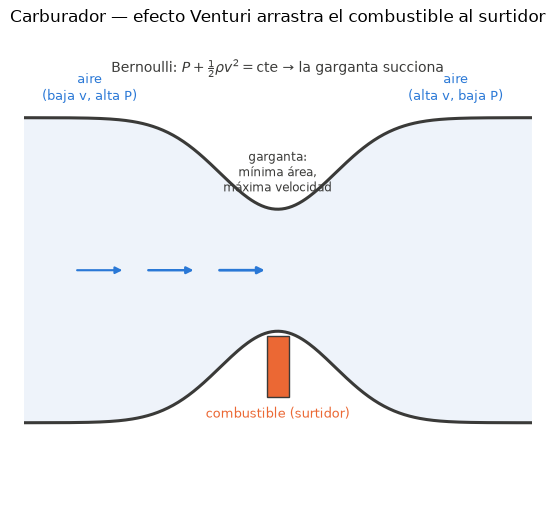

In [12]:
# Esquema propio — tobera Venturi del carburador (reemplaza el escaneo degradado del original,
# cuyo texto tenía errores de OCR/generación: "Bicleta de las mariposas", "secumdino"...)
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.linspace(0, 10, 300)
y0 = 4.5                                              # eje central del tubo
semi = 3.0 - 1.8*np.exp(-((x-5)/1.6)**2)              # semi-altura: se angosta suavemente sin cerrarse
techo, piso = y0+semi, y0-semi
ax.fill_between(x, piso, techo, color="#eef3fa", ec="none")
ax.plot(x, techo, color=COL["tinta"], lw=2.2)
ax.plot(x, piso, color=COL["tinta"], lw=2.2)
for xa in [1.0, 2.4, 3.8]:
    ya = y0
    ax.annotate("", xy=(xa+1.0, ya), xytext=(xa, ya),
               arrowprops=dict(arrowstyle="-|>", color=COL["aire"], lw=1.4+xa*0.15))
ax.text(1.3, techo.max()+0.35, "aire\n(baja v, alta P)", color=COL["aire"], fontsize=9.5, ha="center")
ax.text(8.5, techo.max()+0.35, "aire\n(alta v, baja P)", color=COL["aire"], fontsize=9.5, ha="center")
ax.text(5.0, techo.max()+0.9, "Bernoulli: $P+\\frac{1}{2}\\rho v^2=\\text{cte}$ → la garganta succiona",
        ha="center", fontsize=10, color=COL["tinta"])
ax.add_patch(Rectangle((4.78, y0-2.5), 0.44, 1.2, fc=COL["combustion"], ec=COL["tinta"]))
ax.annotate("", xy=(5.0, y0-1.3), xytext=(5.0, y0-2.5),
           arrowprops=dict(arrowstyle="-|>", color=COL["combustion"], lw=2))
ax.text(5.0, y0-2.9, "combustible (surtidor)", ha="center", fontsize=9.5, color=COL["combustion"])
ax.text(5.0, techo.min()+0.35, "garganta:\nmínima área,\nmáxima velocidad", ha="center", fontsize=8.5,
        color=COL["tinta"])
ax.set_xlim(0, 10); ax.set_ylim(0, 9); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Carburador — efecto Venturi arrastra el combustible al surtidor", fontsize=12, pad=14)
plt.tight_layout(); plt.show()

Impacto en el rendimiento: La inyección permite mantener la mezcla cerca del óptimo estequiométrico o incluso operarla en régimen pobre cuando es beneficioso, mejorando la eficiencia de combustible y reduciendo emisiones. Un carburador, en cambio, suele enriquecer la mezcla en aceleraciones (bombeo de aceleración) y en cargas altas para evitar detonación, lo que reduce la eficiencia (combustible extra que no se quema completamente útil). Además, la inyección mejora la respuesta y uniformidad: cada cilindro recibe la misma mezcla, mientras que en un motor carburado puede haber variaciones de distribución entre cilindros. Por esto, al reemplazar carburadores por inyección se logró típicamente un aumento en potencia (del orden de 5-10%) y una disminución en consumo y contaminantes, especialmente en arranques en frío y transitorios. Los motores diésel siempre han usado inyección, ya que necesitan forzosamente inyectar el combustible directamente en aire comprimido (no podría mezclarse por carburación dado que el diésel autoenciende al inyectarse). En motores de gasolina actuales existe la inyección directa en cámara, que mejora aún más el rendimiento (permite mayor compresión efectiva enfriando la cámara con el combustible inyectado y estratificando la mezcla), aunque aumenta las emisiones de partículas. En resumen, la inyección electrónica como accesorio clave ha incrementado el rendimiento térmico del motor al optimizar la mezcla en cada instante​, frente al carburador que era un compromiso fijo.

In [13]:
# WIDGET 5 — carburador (λ deriva con RPM/carga) vs. inyección (λ controlado) — fenómeno cualitativo
# calibrado para reproducir el comportamiento descrito en la prosa (enriquecimiento en aceleración/
# plena carga); no es un modelo de fluidos de primeros principios, es una representación pedagógica.
def widget5_carburador(rpm=3000.0, carga_pct=60.0):
    rpms = np.linspace(800, 6500, 200)
    cargas = np.linspace(10, 100, 200)
    RPM, CARGA = np.meshgrid(rpms, cargas)
    # carburador: se enriquece (lambda<1) en carga alta y en RPM altas (aceleracion); pobre en ralenti frio
    lam_carb = 1.0 - 0.20*(CARGA/100)**1.5 - 0.12*np.clip((RPM-4500)/2000, 0, 1)
    lam_iny = np.full_like(RPM, 1.0)     # inyección: siempre estequiométrico (o el mapa que la ECU decida)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for ax, LAM, nom in [(axs[0], lam_carb, "Carburador"), (axs[1], lam_iny, "Inyección electrónica")]:
        cf = ax.contourf(RPM, CARGA, LAM, levels=np.linspace(0.75, 1.05, 25), cmap="RdYlBu_r")
        ax.axhline(carga_pct, color=COL["tinta"], lw=1, ls=":")
        ax.axvline(rpm, color=COL["tinta"], lw=1, ls=":")
        ax.set_xlabel("RPM"); ax.set_ylabel("carga [%]"); ax.set_title(nom)
    plt.colorbar(cf, ax=axs[1], label="λ (1=estequiométrico, <1=mezcla rica)")
    lam_carb_pt = float(np.interp(carga_pct, cargas, lam_carb[:, np.searchsorted(rpms, rpm)]))
    axs[0].plot(rpm, carga_pct, "o", ms=10, color="white", mec=COL["tinta"], mew=1.5)
    axs[0].annotate(f"λ={lam_carb_pt:.2f}", (rpm, carga_pct), textcoords="offset points",
                    xytext=(10, 8), fontsize=10, color=COL["tinta"])
    axs[1].plot(rpm, carga_pct, "o", ms=10, color="white", mec=COL["tinta"], mew=1.5)
    axs[1].annotate("λ=1.00", (rpm, carga_pct), textcoords="offset points",
                    xytext=(10, 8), fontsize=10, color=COL["tinta"])
    fig.suptitle("El carburador deriva de estequiométrico con RPM/carga; la inyección lo mantiene fijo",
                fontsize=11)
    plt.tight_layout(); plt.show()

interact(widget5_carburador,
         rpm=FloatSlider(3000, min=800, max=6500, step=100, description="RPM"),
         carga_pct=FloatSlider(60, min=10, max=100, step=5, description="carga [%]"));

interactive(children=(FloatSlider(value=3000.0, description='RPM', max=6500.0, min=800.0, step=100.0), FloatSl…

### Sistema de encendido: Distribuidor, bobina y bujías

## 5. Sistema de Chispa en SI

Los motores de gasolina requieren una chispa para iniciar la combustión de la mezcla aire-combustible. El sistema de encendido incluye una bobina de alta tensión (o varias) y las bujías en cada cilindro. En motores antiguos, un distribuidor mecánico se encargaba de sincronizar y distribuir el pulso de alta tensión de la bobina a cada bujía en el momento adecuado. El distribuidor tenía un eje impulsado por el motor, con levas que abrían y cerraban contactos (platinos) para generar la chispa, y un rotor que apuntaba sucesivamente a los terminales de cada cilindro, "distribuyendo" así la chispa a las bujías correspondientes. Además incorporaba mecanismos para adelantar el encendido según las RPM (avance centrífugo) y la carga (avance por vacío), de forma que la chispa ocurra unos grados antes del PMS cuando el régimen lo requiere. Actualmente, los distribuidores mecánicos han sido sustituidos por sistemas electrónicos: sensores de posición del cigüeñal/camión, módulos de control y bobinas individuales o grupales (sistema DIS o coil-on-plug), eliminando partes móviles y permitiendo un control mucho más preciso y adaptable del timing de encendido.

![Ignition](https://cdn-0.extrudesign.com/wp-content/uploads/2019/05/Ignition-System-in-SI-Engine-extrudesign.com-002.png)

Impacto en el rendimiento: El timing de encendido óptimo es crítico para el rendimiento. Una chispa demasiado atrasada (cerca o después de PMS) provoca combustión tardía, la presión máxima ocurre ya con el pistón bajando y se pierde trabajo (motor perezoso y caliente). Una chispa demasiado adelantada puede causar detonación (knock) o picos de presión antes de PMS que oponen resistencia al pistón, dañando el motor. El distribuidor (o equivalente electrónico) ajusta el encendido para cada condición de funcionamiento. Con un buen control de avance, el motor consigue que la combustión ocurra principalmente cerca del PMS, maximizando la presión útil​y evitando detonaciones. Esto mejora tanto la potencia como la eficiencia: más trabajo útil de cada explosión y menos energía perdida en el cilindro/catalizador por combustión incompleta. Los sistemas modernos incluso pueden variar el avance cilindro a cilindro y ciclo a ciclo usando retroalimentación de sensores de detonación, logrando siempre el punto casi óptimo. En síntesis, el sistema de encendido (y su correcto calibrado) asegura que el motor opere con la máxima presión efectiva ocurrida en el momento adecuado, lo que se traduce en mayor rendimiento. Un mal encendido (p.ej. bujías desgastadas, chispa débil o mal tiempo) provoca pérdidas notables de potencia, aumento de consumo y emisiones de hidrocarburos sin quemar.

In [14]:
# Núcleo del Widget 6 — combustión con liberación de calor gradual (perfil tipo Wiebe) a partir de
# un ángulo de chispa ajustable; T(θ) combina el enfriamiento por expansión (V crece) con el calor
# liberado, y P(θ)=mRT/V (gas ideal, masa fija: válvulas cerradas en toda esta ventana)
def simular_encendido(theta_spark=-20.0, dur=40.0, r=8.5, n_comp=1.30, n_exp=1.30,
                      P1=101325.0, T1=288.0, T3_full=2400.0,
                      bore=0.086, stroke=0.086, conrod=0.145, frames=500):
    R = stroke/2.0; A = 0.25*np.pi*bore**2
    Vs = A*stroke; Vc = Vs/(r-1.0); V1 = Vc+Vs
    theta = np.linspace(-180, 180, frames)          # 0 = TDC (combustión)
    th_rad = np.deg2rad(theta)
    x = (R+conrod) - (R*np.cos(th_rad) + np.sqrt(conrod**2-(R*np.sin(th_rad))**2))
    V = Vc + A*x
    m = P1*V1/(Rgas*T1)

    T_comp_local = T1*(V1/V)**(n_comp-1)             # T si NO hubiera combustión (solo compresión/expansión)
    x_quema = np.clip((theta-theta_spark)/dur, 0, 1)
    frac = 0.5*(1-np.cos(np.pi*x_quema))              # fracción de calor liberado (perfil suave tipo Wiebe)
    T = np.where(theta <= theta_spark, T_comp_local, np.nan)

    mask_comb = (theta > theta_spark) & (theta <= theta_spark+dur)
    T[mask_comb] = T_comp_local[mask_comb] + frac[mask_comb]*(T3_full-T_comp_local[mask_comb])
    idxs_comb = np.where(mask_comb)[0]
    T_end = T[idxs_comb[-1]] if len(idxs_comb) else T_comp_local[np.searchsorted(theta, theta_spark)]
    V_end = V[idxs_comb[-1]] if len(idxs_comb) else np.interp(theta_spark, theta, V)
    mask_exp = theta > theta_spark+dur
    T[mask_exp] = T_end*(V_end/V[mask_exp])**(n_exp-1)

    P = m*Rgas*T/V
    return theta, V, P, T

def trabajo_ventana(V, P):
    return np.sum(0.5*(P[:-1]+P[1:])*(V[1:]-V[:-1]))

_thetas_mbt = np.linspace(-50, 5, 56)
_Ws_mbt = [trabajo_ventana(*simular_encendido(theta_spark=ts)[1:3]) for ts in _thetas_mbt]
THETA_MBT, W_MBT = _thetas_mbt[int(np.argmax(_Ws_mbt))], max(_Ws_mbt)
print(f"simular_encendido() listo — MBT (avance óptimo) ≈ {THETA_MBT:.0f}° APMS para estos parámetros base")

simular_encendido() listo — MBT (avance óptimo) ≈ -10° APMS para estos parámetros base


In [15]:
# WIDGET 6 — avance de encendido: pico de presión vs. PMS, riesgo de detonación / combustión tardía
def widget6_encendido(theta_spark=-20.0, dur=40.0, rpm=3000.0):
    theta, V, P, T = simular_encendido(theta_spark=theta_spark, dur=dur)
    W = trabajo_ventana(V, P)
    i_pico = np.argmax(P)
    theta_pico = theta[i_pico]
    fig, ax = plt.subplots(figsize=(8.5, 5.3))
    ax.plot(theta, P/1e5, color=COL["aire"], lw=2.2)
    ax.axvline(0, color=COL["tinta"], lw=1.2, ls=":")
    ax.text(0.5, P.max()/1e5*0.02, "PMS", fontsize=9, color=COL["tinta"])
    ax.plot(theta_pico, P[i_pico]/1e5, "o", ms=10, color=COL["perdida"], mec="white", mew=1.3)
    ax.axvspan(theta_spark, theta_spark+dur, color=COL["combustion"], alpha=0.15)
    ax.text(theta_spark+dur/2, P.max()/1e5*1.06, "combustión", ha="center", fontsize=9, color=COL["combustion"])
    pct_mbt = W/W_MBT*100
    veredicto = ("⚠ riesgo de detonación (pico muy antes del PMS)" if theta_pico < -8 else
                "combustión tardía — pérdida de trabajo" if pct_mbt < 90 and theta_spark > THETA_MBT else
                "cerca del óptimo (MBT)")
    ax.set_xlabel("ángulo de cigüeñal [° respecto al PMS]"); ax.set_ylabel("Presión [bar]")
    ax.set_title(f"chispa en {theta_spark:.0f}° APMS | pico en {theta_pico:.0f}° | "
                f"W = {pct_mbt:.0f} % del máximo (MBT≈{THETA_MBT:.0f}°)\n{veredicto}", fontsize=10.5)
    ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget6_encendido,
         theta_spark=FloatSlider(-20.0, min=-45, max=5, step=1, description="chispa [°APMS]"),
         dur=FloatSlider(40.0, min=20, max=70, step=2, description="duración [°]"),
         rpm=FloatSlider(3000, min=800, max=6500, step=100, description="RPM (referencia)"));

interactive(children=(FloatSlider(value=-20.0, description='chispa [°APMS]', max=5.0, min=-45.0, step=1.0), Fl…

**Explora con el widget:** mueve la chispa hacia atrás (hacia 0° o positivo) y el pico de presión se retrasa más allá del PMS — el trabajo cae porque el pistón ya está bajando cuando llega la presión máxima ("combustión tardía"). Adelántala demasiado (más negativo que el óptimo) y el pico ocurre *antes* del PMS, con el pistón todavía subiendo — eso es exactamente la condición de detonación que describe la prosa. El punto MBT (*maximum brake torque*) es el equilibrio entre ambos extremos.

## 6. Sistema de válvulas: Árbol de levas y apertura de válvulas

El árbol de levas (o leva a secas) es el componente que abre y cierra las válvulas de admisión y escape en sincronía con el movimiento del pistón.

![3.5EcoboostCombustion](https://upload.wikimedia.org/wikipedia/commons/f/f4/3.5EcoboostCombustion.jpg)

![NISSAN_SR20VE_CYL-HEAD](https://upload.wikimedia.org/wikipedia/commons/9/90/NISSAN_SR20VE_CYL-HEAD_02.jpg)

![Ovalpiston](https://upload.wikimedia.org/wikipedia/commons/1/18/Ovalpiston.jpg)

En un motor típico hay al menos una leva para admisión y una para escape por cilindro (motores OHV antiguos tenían el árbol de levas en el bloque y varillas impulsoras, la mayoría de motores modernos son OHC/DOHC con árboles de levas en la culata actuando directamente o vía balancines sobre las válvulas). El perfil de cada leva determina el tiempo de apertura de la válvula (duración en grados de cigüeñal), el levantamiento (apertura máxima) y la forma de apertura/cierre. Estos parámetros afectan cuánta mezcla entra y cuántos gases salen. Por ejemplo, una leva "de altas revoluciones" mantiene las válvulas abiertas más tiempo y con más alzada, permitiendo llenar mejor el cilindro a altas RPM, pero puede provocar solapamiento (admisión y escape abiertas a la vez) pronunciado que a bajas RPM causa reflujo y pérdida de torque.

![variable-valve-camshaft](https://s19539.pcdn.co/wp-content/uploads/2012/06/variable-valve-camshaft.jpg)

> **La física del traslape (*overlap*):** cerca del PMS de escape (θ=0°/720° en el Widget 1), la válvula de escape aún no cierra del todo y la de admisión ya empieza a abrir — ambas están abiertas a la vez. A **alta RPM** esto ayuda: la inercia de la columna de gases de escape que sale genera una succión que ayuda a "arrastrar" la carga fresca (efecto de sintonía/resonancia). A **baja RPM** el mismo traslape es contraproducente: sin inercia suficiente, los gases de escape (o incluso la mezcla fresca) refluyen por el camino equivocado, diluyendo la carga y perdiendo par motor — exactamente el fenómeno de "interacción aire-válvulas" que el siguiente widget hace visible.

In [16]:
# WIDGET 7 — perfil de leva, traslape (overlap) de válvulas y su interacción con el aire
def perfil_leva(theta, centro, duracion, alzada_max):
    d = np.mod(theta-centro+180, 360)-180             # distancia angular con signo, en (-180,180]
    within = np.abs(d) <= duracion/2
    lift = np.zeros_like(theta)
    lift[within] = alzada_max*0.5*(1+np.cos(2*np.pi*d[within]/duracion))
    return lift

def widget7_levas(dur_adm=220.0, dur_esc=210.0, avance_adm=8.0, retraso_esc=8.0, alzada=9.0, rpm=3000.0):
    theta = np.linspace(-360, 360, 1500)              # 0 = PMS de intercambio de gases (fin escape/inicio admision)
    # admisión centrada a mitad de su carrera (+90°=mitad de 0-180°), escape a mitad de la suya (-90°);
    # avance/retraso desplazan cada leva HACIA el PMS común, agrandando o encogiendo el traslape
    lift_adm = perfil_leva(theta, centro=90-avance_adm, duracion=dur_adm, alzada_max=alzada)
    lift_esc = perfil_leva(theta, centro=-90+retraso_esc, duracion=dur_esc, alzada_max=alzada)
    overlap_mask = (lift_adm > 0.15) & (lift_esc > 0.15)
    overlap_deg = overlap_mask.sum()*(theta[1]-theta[0])

    fig, ax = plt.subplots(figsize=(9.5, 5))
    ax.plot(theta, lift_adm, color=COL["aire"], lw=2.2, label="admisión")
    ax.plot(theta, lift_esc, color=COL["cerrada"], lw=2.2, label="escape")
    ax.fill_between(theta, 0, np.minimum(lift_adm, lift_esc), where=overlap_mask,
                    color=COL["perdida"], alpha=0.5, label="traslape (overlap)")
    ax.axvline(0, color=COL["tinta"], lw=1, ls=":")
    ax.text(0, alzada*1.08, "PMS\n(escape→admisión)", ha="center", fontsize=8.5, color=COL["tinta"])
    ax.set_xlim(-230, 230); ax.set_ylim(0, alzada*1.25)
    ax.set_xlabel("ángulo de cigüeñal [° respecto al PMS de intercambio]")
    ax.set_ylabel("alzada de válvula [mm]")
    riesgo = "beneficioso a esta RPM (ayuda de inercia)" if rpm > 3500 else "riesgo de reflujo a esta RPM (bajo régimen)"
    ax.set_title(f"Traslape = {overlap_deg:.0f}° de cigüeñal — {riesgo}", fontsize=11)
    ax.legend(loc="upper right"); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget7_levas,
         dur_adm=FloatSlider(220, min=180, max=300, step=5, description="duración adm. [°]"),
         dur_esc=FloatSlider(210, min=180, max=300, step=5, description="duración esc. [°]"),
         avance_adm=FloatSlider(8, min=-10, max=40, step=1, description="avance adm. (VVT) [°]"),
         retraso_esc=FloatSlider(8, min=-10, max=40, step=1, description="retraso esc. (VVT) [°]"),
         alzada=FloatSlider(9, min=5, max=13, step=0.5, description="alzada máx [mm]"),
         rpm=FloatSlider(3000, min=800, max=7000, step=100, description="RPM"));

interactive(children=(FloatSlider(value=220.0, description='duración adm. [°]', max=300.0, min=180.0, step=5.0…

Impacto en el rendimiento: El sistema de distribución controla el llenado y vaciado de los cilindros, influyendo en la llamada eficiencia volumétrica del motor. Un diseño optimizado de válvulas puede lograr que prácticamente entre el 100% (o más, con inercia de resonancia) del volumen del cilindro en aire fresco a determinadas RPM. Si las válvulas son muy pequeñas o se abren poco tiempo, restringen el flujo de aire, limitando la cantidad de mezcla que entra y reduciendo la potencia (el motor "no respira" bien). Por eso, muchos motores han adoptado 4 válvulas por cilindro en lugar de 2 – así aumentan el área de flujo, mejorando el rendimiento a altas RPM. Asimismo, sistemas de válvulas de tiempo variable (VVT) permiten modificar el tiempo de apertura/cierre según el régimen: por ejemplo, adelantar la apertura de admisión y retrasar el cierre a altas RPM para maximizar llenado, o reducir el solapamiento a bajas cargas para mejor estabilidad y consumo. Tecnologías como VTEC, VANOS, VVT-i, etc., logran un compromiso dinámico entre potencia máxima y eficiencia a baja carga. En términos de ciclo $P$–$V$, un buen diseño de distribución reduce las pérdidas de bombeo: en condiciones de alta carga, una admisión plena (sin estrangular y con válvulas adecuadas) hace que el trazo de admisión 0-1 esté cercano a la presión atmosférica, minimizando el área negativa de bombeo​. Igualmente, una evacuación eficiente de gases de escape reduce la contrapresión en 4-1. Todo esto mejora el trabajo neto. Si las válvulas están mal sincronizadas, el motor puede perder una fracción importante de aire fresco (escape prematuro) o aspirar menos de lo posible (cierre temprano/tardío), bajando potencia y eficiencia. En resumen, el sistema de levas y válvulas bien afinado permite que el motor tome más aire (y queme más combustible de forma útil) y desperdicie menos trabajo en mover esos gases, aumentando tanto la potencia máxima como el rendimiento térmico (especialmente a distintas velocidades de giro).

## 7. Sistema de refrigeración

La refrigeración del motor (generalmente por líquido con radiador, bomba, termostato y camisas de agua en el bloque y la culata, aunque algunos motores pequeños son refrigerados por aire) tiene como objetivo mantener las partes del motor dentro de un rango de temperaturas seguro. La combustión genera temperaturas muy altas (hasta ~2500 K en el frente de llama), y sin un enfriamiento adecuado componentes como la culata, pistón o válvulas se sobrecalentarían, provocando fallos catastróficos (agarrotamiento, autodetonación, queme de válvulas). El sistema de refrigeración extrae parte del calor de las paredes y lo disipa (en el radiador al aire ambiente).

![Jupiter engine](https://upload.wikimedia.org/wikipedia/commons/2/28/Jupiter.engine.arp.750pix.jpg)

![esquema refrigeracion](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEhsi4twR3fWKk5WvPTc5nuO6r71rTqVOVplq2Va9jCDfK5osx0YL42lGmNDX7sXx8ljgQyJVvKjk_ACrw5PZqsa596v0nE5XyhManJ6JvKvHATOjVbAVmOLPMXNhe_11pHeoq64w9iQ5QU/s640/esquema+refirgeraci%C3%B3n+motores.jpg)

![enfriamiento](https://buscadordetalleres.com/blog/wp-content/uploads/2021/05/6.jpg)

![diagrama enfriamiento](https://cdn.club-magazin.autodoc.de/uploads/sites/11/2020/11/diagrama-del-sistema-de-enfriamiento.jpg)

Impacto en el rendimiento: La refrigeración es un mal necesario: por un lado, quita calor que de otro modo podría haberse aprovechado para hacer trabajo (es una pérdida térmica directamente relacionada con la disminución de eficiencia del ciclo real​). Por otro lado, sin ella el motor no podría operar de forma sostenida, y un control adecuado de la temperatura puede incluso mejorar la eficiencia. Los motores están diseñados para operar a una temperatura específica (p. ej., ~90°C en el líquido refrigerante). El termostato ayuda a que alcancen esa temperatura rápidamente y la mantengan. Un motor demasiado frío (por debajo de su temperatura óptima) tendrá mayores pérdidas por fricción (el aceite está más viscoso) y una combustión menos eficiente (la gasolina condensa en las paredes frías, la mezcla en frío necesita enriquecer, etc.), reduciendo el rendimiento. Un motor demasiado caliente puede sufrir autodetonación porque las paredes calientes inflaman prematuramente la mezcla, además de riesgo de daños; aunque termodinámicamente, cuanto más caliente se conserve los gases durante la expansión, más trabajo se extrae. Así pues, existe un punto óptimo. El sistema de refrigeración bien regulado asegura que el motor funcione cerca de ese punto, otorgando un balance entre eficiencia y confiabilidad. Algunos avances incluyen gestión activa de temperatura, con bombas eléctricas y válvulas que permiten calentar más rápido ciertas partes o operar el motor un poco más caliente bajo baja carga para ahorro de combustible, etc. En motores sobrealimentados, el sistema de refrigeración también se extiende a intercoolers que enfrían el aire de admisión comprimido (lo que aumenta la densidad de aire y potencia, y también reduce la tendencia a detonación). En síntesis, aunque la refrigeración roba una parte de la energía (representada en el ciclo real por las líneas politrópicas en lugar de adiabáticas), es imprescindible para lograr cualquier rendimiento – un motor roto o detonando no produce potencia útil. Con materiales avanzados (cerámicas, recubrimientos) se busca reducir la necesidad de enfriamiento en zonas críticas y aprovechar mejor el calor, pero en la práctica la mayor parte de motores dedica alrededor del ~20–30% de la energía a calentar el líquido refrigerante.

## 8. Sobrealimentación: Turbocargador (Turbo)

El turbocargador es un compresor de admisión impulsado por una turbina movida por los gases de escape. Su función es aumentar la presión y densidad del aire que entra al cilindro. En términos sencillos, el turbo mete más aire en cada ciclo, permitiendo quemar más combustible y generar más potencia sin aumentar la cilindrada. Aprovecha la energía de los gases de escape (que de otro modo se perdería) para comprimir el aire de admisión.

![turbo tooling](https://cdn2.sandvik.coromant.com/files/a53b485b-be0f-019d-8100-3f0d1619b9fa/55694d52-5d38-421c-9029-a5fa009210f6/tooling-solutions-for-machining-of-turbo-charger-and-turbo-housing-in-iso-k-and-iso-n-materials_jpg.webp)

![Turbocharger](https://upload.wikimedia.org/wikipedia/commons/7/76/Turbocharger.jpg)

Impacto en el rendimiento: La influencia de un turbo en la potencia es muy significativa. Al comprimir el aire de admisión, se introduce mayor masa de oxígeno en la cámara, y al inyectar proporcionalmente más combustible se logra una combustión más potente, liberando más energía por ciclo​. En otras palabras, el turbo aumenta la densidad de la mezcla aire-combustible, elevando la presión media de combustión y por tanto el trabajo generado​. Un motor con turbo puede fácilmente superar en un 50% o más la potencia del mismo motor aspirado. Además, al recuperar parte de la energía de escape, mejora la eficiencia global: se puede obtener más trabajo útil de la misma energía calorífica (especialmente a cargas altas). Sin embargo, el efecto exacto en la eficiencia depende de cómo se use el turbo. Si el turbo permite usar un motor más pequeño para la misma potencia (concepto de downsizing), entonces a cargas parciales el motor pequeño turbo operará con mayor carga relativa y mejor eficiencia que un grande sin turbo estrangulado – ahorrando combustible. De hecho, muchos automóviles modernos logran mejores consumos con pequeños motores turbo. Por otro lado, si simplemente añadimos turbo a un motor y el conductor utiliza la potencia extra, el consumo absoluto subirá (porque se quema más combustible), aunque la eficiencia por unidad de potencia puede ser ligeramente mejor. El turbo tiende a aumentar el rendimiento en motores Diesel más notablemente que en gasolina​, porque el diésel siempre trabaja con exceso de aire y al añadir más aire puede quemar más combustible eficientemente sin problemas de mezcla; en gasolina, al meter más aire se debe enriquecer la mezcla y además hay riesgo de detonación, que se mitiga con intercooler y reduciendo compresión geométrica.

Los inconvenientes del turbo incluyen el conocido turbo-lag (retardo): a bajas RPM el flujo de escape es insuficiente para impulsar la turbina, de modo que el incremento de presión de admisión se nota solo tras subir de vueltas. Para mitigarlo se usan turbos de geometría variable, turbocompresores dobles (bi-turbo secuencial) o combinaciones turbo + supercargador mecánico. Un supercargador es similar en función (comprimir admisión) pero recibe el movimiento directamente del motor (por correa), así que aumenta el consumo parasitario – se usa en algunas aplicaciones por su respuesta inmediata. El turbocargador en cambio "gratis" usa energía de escape, por lo que conceptualmente mejora la eficiencia termodinámica aprovechando energía residual. Como dato, un motor gasolina turbo moderno puede alcanzar ~35–38% de eficiencia (mejor que ~25–30% de uno aspirado), y un diésel turbo cerca de 40–45%.

![turbo esquema](https://zagacarperu.com/wp-content/uploads/2024/08/2-1024x572.png)

### 8.1. Modelación del ciclo turbocargado

En los ciclos $P$–$V$, un motor turbo se refleja principalmente en que el proceso de admisión se realiza a una presión mayor que atmosférica. La línea de admisión en el diagrama indicado sube, incrementando el área del ciclo (trabajo neto). Además, al haber más masa de aire y combustible, las presiones de combustión y expansión son mayores, elevando aún más el trabajo. El turbocargador también eleva algo la temperatura inicial $T_1$ del aire (ya que comprime y calienta, aunque el intercooler reduce esto), lo que tiene efectos menores en eficiencia (aire más caliente disminuye la densidad ganada, pero suele compensarse con el intercooler).

En resumen, el turbocargador es un accesorio casi indispensable en motores modernos por su enorme impacto positivo en la potencia (permite prácticamente doblar la potencia de un motor dado) y su potencial para mejorar la eficiencia al permitir reducir cilindrada y aprovechar calor de escape​. La gestión electrónica actual (wastegates controladas, geometría variable, inyección adaptativa) ha mitigado muchos de sus inconvenientes, haciendo que tanto motores gasolina como diésel turboalimentados dominen el mercado.

In [17]:
# WIDGET 8 — turbo Otto/Diesel unificado (consolida y anima las celdas 39-40 del original)
def widget8_turbo(modo="Otto", P_boost_kPa=50.0):
    if modo == "Otto":
        base = ciclo_otto(r=8.5, T3=2073.0, real=True)
        turbo = ciclo_otto(r=8.5, T3=2073.0, n_comp=1.30, n_exp=1.35, real=True)
        col = COL["aire"]
    else:
        base = ciclo_diesel(r=18.0, rho=2.0, real=True)
        turbo = ciclo_diesel(r=18.0, rho=2.0, n_comp=1.32, n_exp=1.37, real=True)
        col = COL["diesel"]
    P_boost = P_boost_kPa*1e3
    factor = (101325.0+P_boost)/101325.0
    fig, ax = plt.subplots(figsize=(8.5, 5.6))
    ax.plot(base["V"], base["P"]/1e3, color=col, lw=2.2, label=f"{modo} aspirado")
    ax.plot(base["V"], base["P"]*factor/1e3, color=COL["perdida"], lw=2.2, ls="--",
            label=f"{modo} turbo (+{P_boost_kPa:.0f} kPa)")
    ax.fill_between(base["V"], base["P"]/1e3, base["P"]*factor/1e3, color=COL["perdida"], alpha=0.12)
    ax.set_xlabel("Volumen [relativo]"); ax.set_ylabel("Presión [kPa]")
    ganancia = (factor-1)*100
    ax.set_title(f"{modo}: sobrealimentar +{P_boost_kPa:.0f} kPa → +{ganancia:.0f} % de trabajo neto "
                f"(mismas T y masas relativas)", fontsize=10.5)
    ax.legend(); ax.grid(alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget8_turbo,
         modo=Dropdown(options=["Otto", "Diesel"], description="motor"),
         P_boost_kPa=FloatSlider(50, min=0, max=150, step=5, description="boost [kPa]"));

interactive(children=(Dropdown(description='motor', options=('Otto', 'Diesel'), value='Otto'), FloatSlider(val…

## 9. Sistema de Lubricación

Otros sistemas, como el sistema de lubricación (bomba de aceite, filtros) reducen la fricción interna y por ende las pérdidas mecánicas, incrementando la eficiencia mecánica del motor (la proporción de la potencia indicada que llega a la salida del cigüeñal).

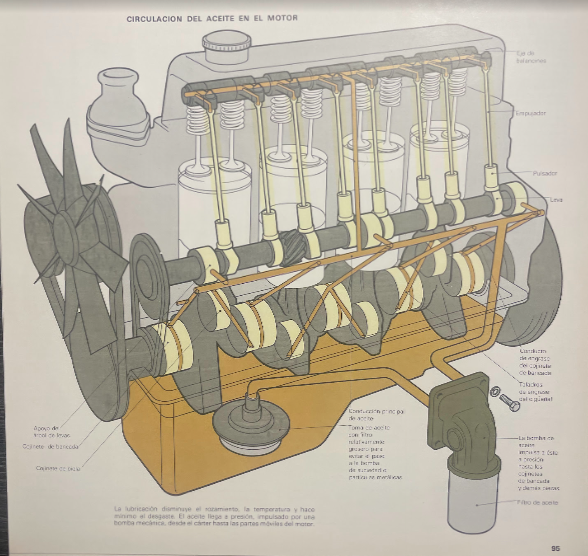

*Circulación del aceite en el motor — imagen de referencia conservada.*

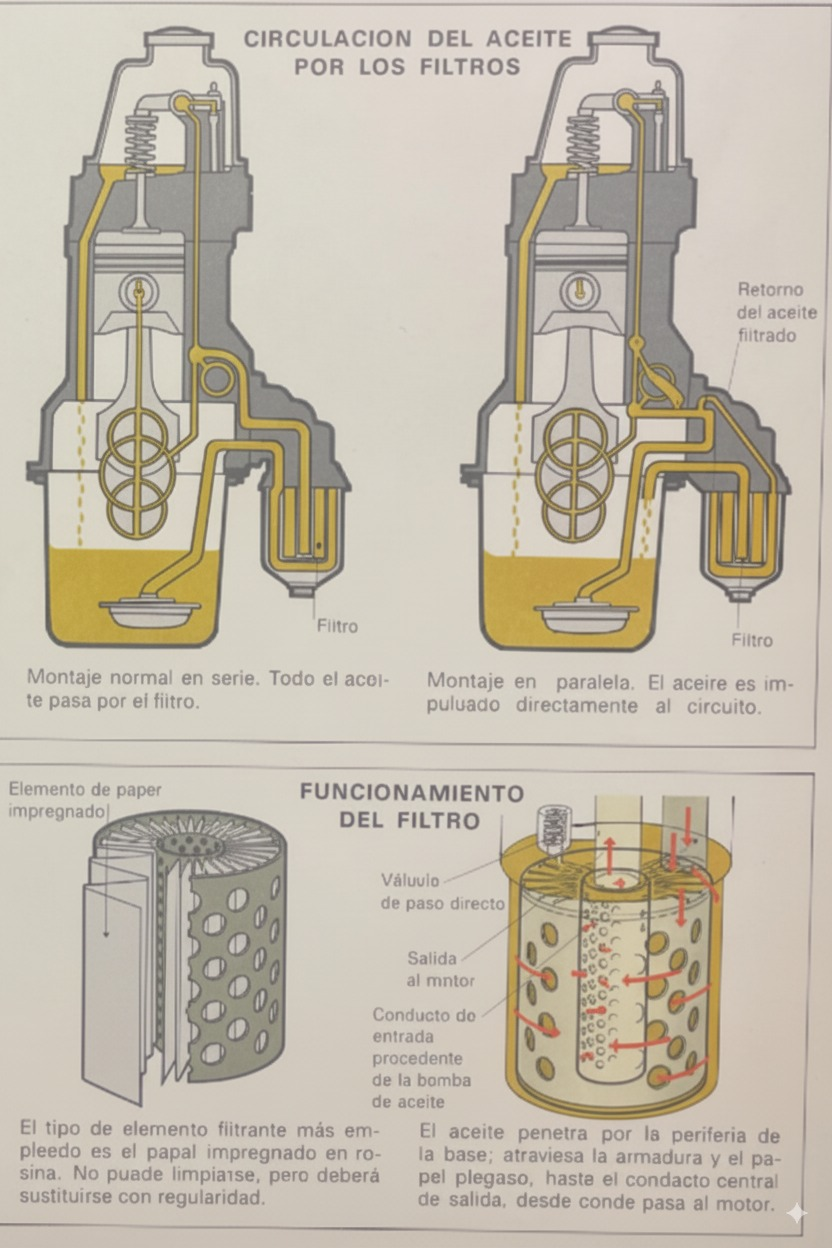

*Circulación del aceite por los filtros y funcionamiento del filtro — imagen de referencia conservada.*

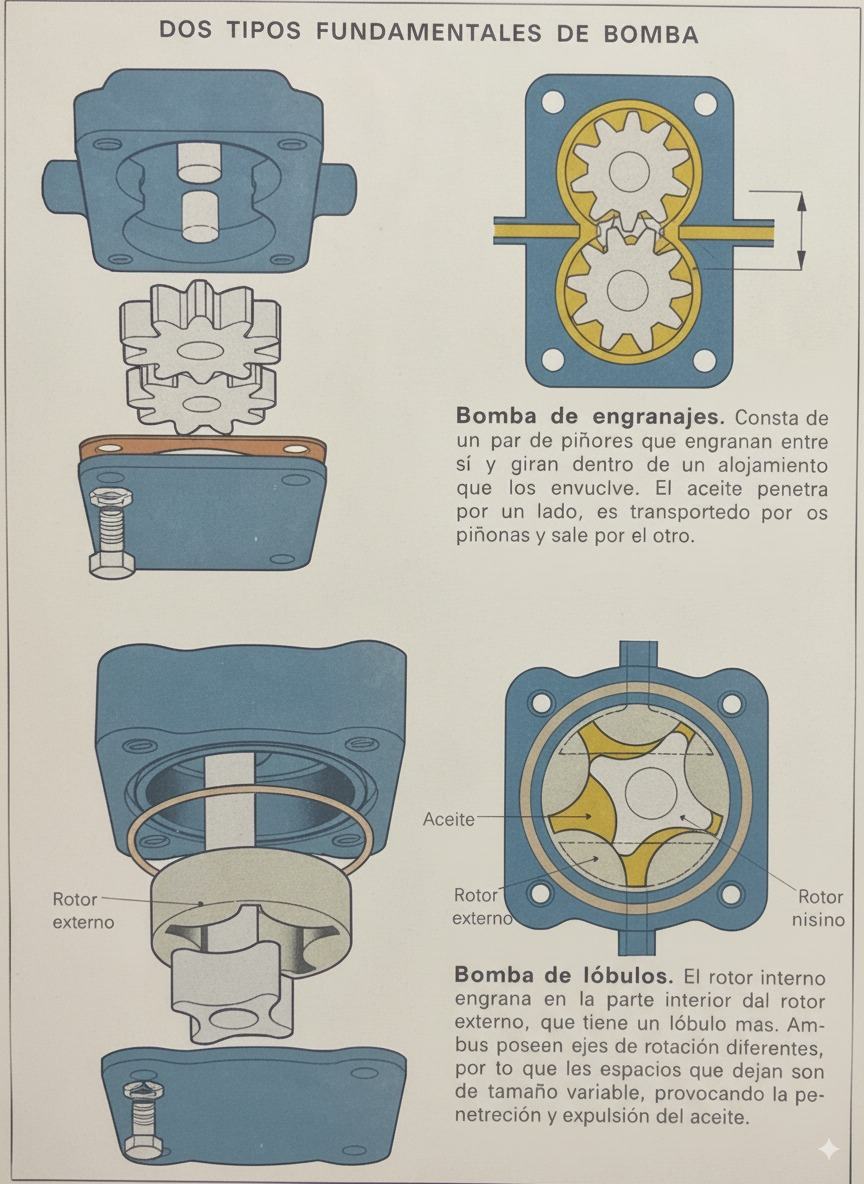

*Dos tipos fundamentales de bomba de aceite: de engranajes y de lóbulos — imagen de referencia conservada (la bomba de lóbulos es, mecánicamente, un Roots en miniatura — Lección 10, §7.1).*

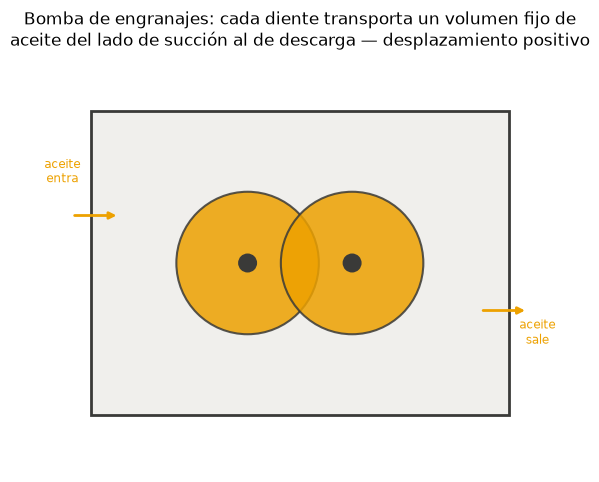

In [18]:
# Esquema propio — bomba de aceite de engranajes (complementa la imagen de referencia; mismo
# principio que el compresor Roots de la Lección 10, aplicado a un líquido)
fig, ax = plt.subplots(figsize=(6, 5))
ax.add_patch(Rectangle((-2.2, -1.6), 4.4, 3.2, fc="#f0efec", ec=COL["tinta"], lw=2))
for cx in (-0.55, 0.55):
    ax.add_patch(Circle((cx, 0), 0.75, fc=COL["aceite"], ec=COL["tinta"], lw=1.5, alpha=0.85))
    ax.add_patch(Circle((cx, 0), 0.1, fc=COL["tinta"]))
ax.annotate("", xy=(-1.9, 0.5), xytext=(-2.4, 0.5),
           arrowprops=dict(arrowstyle="-|>", color=COL["aceite"], lw=2))
ax.text(-2.5, 0.85, "aceite\nentra", ha="center", fontsize=8.5, color=COL["aceite"])
ax.annotate("", xy=(2.4, -0.5), xytext=(1.9, -0.5),
           arrowprops=dict(arrowstyle="-|>", color=COL["aceite"], lw=2))
ax.text(2.5, -0.85, "aceite\nsale", ha="center", fontsize=8.5, color=COL["aceite"])
ax.set_xlim(-3, 3); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Bomba de engranajes: cada diente transporta un volumen fijo de\naceite del lado de succión al de descarga — desplazamiento positivo")
plt.tight_layout(); plt.show()

## 10. Unidad de Control Electrónica (ECU)

La unidad de control electrónica (ECU) no es un accesorio físico mecánico, pero es clave para gestionar óptimamente los anteriores (inyección, encendido, turbo, incluso válvulas en motores con distribución variable electrónica), maximizando en todo momento el rendimiento y protegiendo al motor. Sistemas de escape optimizados (colectores calibrados, convertidores catalíticos de flujo libre) también pueden reducir la contrapresión y mejorar ligeramente el rendimiento. Múltiples bujías por cilindro (como en algunos diseños) aseguran una combustión más rápida y completa. Incluso accesorios externos como ventiladores, alternador, compresor de aire acondicionado, etc., afectan el rendimiento percibido porque consumen parte del trabajo del motor; por ello se trabaja en alternadores inteligentes, compresores eléctricos, etc., para minimizar su impacto cuando no son necesarios.

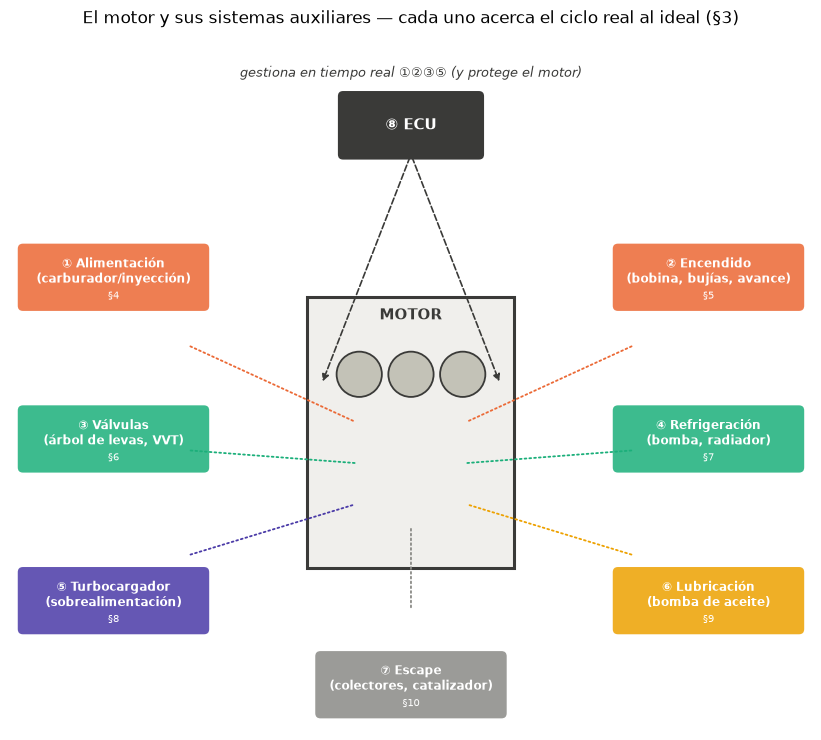

In [19]:
# Diagrama capstone — el motor y sus 8 sistemas auxiliares (reemplaza el enlace de la celda original,
# que apuntaba a una foto de Facebook con token de expiración: se habría roto tarde o temprano)
fig, ax = plt.subplots(figsize=(10.5, 7.5))
ax.add_patch(Rectangle((-1.6, -1.5), 3.2, 4.2, fc="#f0efec", ec=COL["tinta"], lw=2.2))
for cx in (-0.8, 0.0, 0.8):
    ax.add_patch(Circle((cx, 1.5), 0.35, fc=COL["metal"], ec=COL["tinta"], lw=1.3))
ax.text(0, 2.35, "MOTOR", ha="center", fontsize=11, fontweight="bold", color=COL["tinta"])

sistemas = [
    (-4.6, 3.0, "① Alimentación\n(carburador/inyección)", COL["combustion"], "§4"),
    (4.6, 3.0, "② Encendido\n(bobina, bujías, avance)", COL["combustion"], "§5"),
    (-4.6, 0.5, "③ Válvulas\n(árbol de levas, VVT)", COL["abierta"], "§6"),
    (4.6, 0.5, "④ Refrigeración\n(bomba, radiador)", COL["agua"], "§7"),
    (-4.6, -2.0, "⑤ Turbocargador\n(sobrealimentación)", COL["diesel"], "§8"),
    (4.6, -2.0, "⑥ Lubricación\n(bomba de aceite)", COL["aceite"], "§9"),
    (0, -3.3, "⑦ Escape\n(colectores, catalizador)", COL["cerrada"], "§10"),
]
for sx, sy, nombre, col, ref in sistemas:
    ax.add_patch(FancyBboxPatch((sx-1.4, sy-0.44), 2.8, 0.88, boxstyle="round,pad=0.08",
                                fc=col, alpha=0.85, ec="none"))
    ax.text(sx, sy+0.09, nombre, ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
    ax.text(sx, sy-0.33, ref, ha="center", fontsize=7.5, color="white")
    ax.annotate("", xy=(sx*0.18, sy*0.25), xytext=(sx*0.75, sy*0.65),
               arrowprops=dict(arrowstyle="-", color=col, lw=1.3, ls=":"))

ax.add_patch(FancyBboxPatch((-1.05, 4.9), 2.1, 0.9, boxstyle="round,pad=0.08",
                            fc=COL["tinta"], ec="none"))
ax.text(0, 5.35, "⑧ ECU", ha="center", va="center", fontsize=11, color="white", fontweight="bold")
for sx, sy, *_ in sistemas[:2]:
    ax.annotate("", xy=(sx*0.3, sy*0.35+0.3), xytext=(0, 4.9),
               arrowprops=dict(arrowstyle="-|>", color=COL["tinta"], lw=1.2, ls="--"))
ax.text(0, 6.1, "gestiona en tiempo real ①②③⑤ (y protege el motor)", ha="center", fontsize=9,
        color=COL["tinta"], style="italic")

ax.set_xlim(-6.2, 6.2); ax.set_ylim(-4.0, 6.8); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("El motor y sus sistemas auxiliares — cada uno acerca el ciclo real al ideal (§3)",
             fontsize=12.5)
plt.tight_layout(); plt.show()

Los accesorios del motor – desde la forma de dosificar combustible y encenderlo, hasta cómo se gestionan los gases y la temperatura – juegan un papel crucial en el rendimiento global. Un ciclo termodinámico óptimo solo se alcanza en la realidad gracias a la interacción de todos estos sistemas afinados: una mezcla precisa (inyección), encendida en el momento justo (distribución/ECU), introducida y expulsada con mínimas pérdidas (válvulas bien calibradas, turboalimentación) y manteniendo el motor en rango térmico ideal (refrigeración). Las mejoras históricas en potencia, eficiencia y fiabilidad de los motores de combustión interna se deben en gran medida a la evolución de estos accesorios y sistemas auxiliares. Cada componente añadido o perfeccionado acerca el comportamiento del motor real un poco más al ideal teórico, permitiendo aprovechar mejor la energía del combustible en movimiento útil en las ruedas.

## Verificación

Cuatro contrastes con tolerancia < 1 %: (1) el simulador animado del Widget 1 (`simular_motor`, caso ideal $n=k$, sin blowdown) contra la fórmula cerrada de `ciclo_otto()`; (2) lo mismo para `ciclo_diesel()`; (3) la eficiencia del ciclo Diesel ideal (Widget 4) contra la fórmula estándar $\eta=1-\frac{1}{r^{k-1}}\left[\frac{\rho^k-1}{k(\rho-1)}\right]$; (4) el ejemplo Otto resuelto a mano (§3.4, $c_v$=0.718 kJ/(kg·K) fijo) contra el mismo cálculo con propiedades reales de CoolProp.

In [20]:
# Celda de verificación
k = k0
# 1) simular_motor (Otto, ideal) vs ciclo_otto() cerrado
sim_o = simular_motor(modo="Otto", r=9.0, n_comp=k, n_exp=k, T3_otto=2400.0, f_blowdown=0.999)
W_sim_o = trabajo_motor(sim_o["V"], sim_o["P"])
m_o = 101325.0*sim_o["V1"]/(Rgas*288.0)
w_sim_o = W_sim_o/m_o
cerrado_o = ciclo_otto(r=9.0, T3=2400.0, real=False)
err1 = abs(w_sim_o-cerrado_o["w_net"])/cerrado_o["w_net"]*100
print(f"1) Otto ideal: simular_motor {w_sim_o/1000:.2f} kJ/kg vs ciclo_otto() {cerrado_o['w_net']/1000:.2f} kJ/kg "
      f"(err {err1:.3f} %)")

# 2) simular_motor (Diesel, ideal) vs ciclo_diesel() cerrado
sim_d = simular_motor(modo="Diesel", r=18.0, rho=2.0, n_comp=k, n_exp=k, f_blowdown=0.999)
W_sim_d = trabajo_motor(sim_d["V"], sim_d["P"])
m_d = 101325.0*sim_d["V1"]/(Rgas*288.0)
w_sim_d = W_sim_d/m_d
cerrado_d = ciclo_diesel(r=18.0, rho=2.0, real=False)
err2 = abs(w_sim_d-cerrado_d["w_net"])/cerrado_d["w_net"]*100
print(f"2) Diesel ideal: simular_motor {w_sim_d/1000:.2f} kJ/kg vs ciclo_diesel() {cerrado_d['w_net']/1000:.2f} kJ/kg "
      f"(err {err2:.3f} %)")

# 3) eficiencia Diesel ideal: ciclo_diesel() vs formula directa
r_v, rho_v = 18.0, 2.0
eta_formula = 1 - (1/r_v**(k-1))*((rho_v**k-1)/(k*(rho_v-1)))
eta_ciclo = ciclo_diesel(r=r_v, rho=rho_v, real=False)["eta"]
err3 = abs(eta_formula-eta_ciclo)/eta_formula*100
print(f"3) η Diesel ideal: fórmula {eta_formula*100:.3f} % vs ciclo_diesel() {eta_ciclo*100:.3f} % (err {err3:.4f} %)")

# 4) ejemplo Otto a mano (cv fijo) vs CoolProp (ya calculado en §3.4; se repite aquí el contraste final)
err4 = abs(w_net_mano-w_net_coolprop)/w_net_mano*100
print(f"4) ejemplo §3.4: w_net a mano {w_net_mano/1000:.1f} kJ/kg vs CoolProp {w_net_coolprop/1000:.1f} kJ/kg "
      f"(err {err4:.3f} %)")

assert max(err1, err2, err3, err4) < 1.0, "Verificación fallida: error >= 1 %"
print(f"\n✔ Verificación superada (máx. {max(err1, err2, err3, err4):.3f} % < 1 %)")

1) Otto ideal: simular_motor 716.06 kJ/kg vs ciclo_otto() 716.32 kJ/kg (err 0.036 %)
2) Diesel ideal: simular_motor 580.03 kJ/kg vs ciclo_diesel() 580.19 kJ/kg (err 0.028 %)
3) η Diesel ideal: fórmula 63.132 % vs ciclo_diesel() 63.132 % (err 0.0000 %)
4) ejemplo §3.4: w_net a mano 556.5 kJ/kg vs CoolProp 556.0 kJ/kg (err 0.075 %)

✔ Verificación superada (máx. 0.075 % < 1 %)


## Conclusión

Un motor de combustión interna es la misma física de la Lección 1 vista con un ingrediente añadido: entre la compresión (1→2) y la expansión (3→4) — ambas gobernadas por $PV^n=\text{cte}$, con $n_{comp}<k<n_{exp}$ en el caso real, tal como en el compresor de la Lección 10 — se **inserta calor químico**, y esa inserción es lo que convierte una máquina que consume trabajo en una que lo entrega. Otto lo hace de golpe (volumen constante); Diesel lo dosifica (presión constante) y compensa con mucha más compresión de la que Otto podría tolerar sin detonar. Todo lo demás en esta lección — válvulas con su traslape, chispa con su avance, carburador o inyección, turbo, refrigeración — es ingeniería alrededor de esa única inserción de calor: cada sistema existe para que el calor entre en el momento correcto, con el aire correcto, y para que el motor sobreviva a las temperaturas que produce. La distancia entre el ~53 % ideal del ejemplo de esta lección y el ~25-45 % real de un motor de producción es, literalmente, la suma de todo lo que se estudió en las secciones 4 a 10.

---
### Referencias
- Çengel, Y. A. & Boles, M. A. (2015). *Termodinámica*, 8ª ed. McGraw-Hill — Cap. 9, ciclos de potencia de gas.
- Heywood, J. B. (1988). *Internal Combustion Engine Fundamentals*. McGraw-Hill.
- Taylor, C. F. (1985). *The Internal-Combustion Engine in Theory and Practice*, 2ª ed. MIT Press.
- Pulkrabek, W. W. (2004). *Engineering Fundamentals of the Internal Combustion Engine*, 2ª ed. Pearson.
- Bell, I. H. et al. (2014). CoolProp. *Ind. Eng. Chem. Res.*, 53(6), 2498–2508.